# Australia Multi‑City SUHI (2003–2025)

This notebook consolidates **all analysis + figures + diagnostics** 

**Data**
- MODIS LST (day/night): urban & rural
- MODIS EVI (urban & rural → ΔEVI = urban − rural)
- ERA5 drivers: air temperature, precipitation, wind, relative humidity, cloud fraction, boundary layer height

**Outcomes**
- SUHI = Urban LST − Rural LST
- Seasons: Annual, Summer (DJF), Winter (JJA)
- Time of day: Day & Night

**Models**
- Two‑way fixed effects panel (City + Year)
- Clustered inference (by city) + Driscoll–Kraay sensitivity
- Partial residual diagnostics
- Relative importance (ΔR²)
- Robustness: nonlinearity/interactions, leave‑one‑city‑out, city heterogeneity, urban vs rural symmetry

---

In [1]:
from pathlib import Path

# =========================
# 0) Column names
# =========================
YDAY   = "suhi_day_C"
YNIGHT = "suhi_night_C"

# Core keys
KEYS = ["city", "year", "month"]

# =========================
# 1) Input paths
# =========================
# 1) Monthly SUHI + EVI table
SUHI_CSV = Path(r"G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis\SUHI_monthly_2003_2025.csv")

# 2) Monthly ERA5 table
ERA5_CSV = Path(r"G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis\ERA5_drivers_monthly_2003_2025.csv")

# 3) Outputs folder (figures + tables)
OUTDIR = Path("paper_outputs_final")
(OUTDIR / "figures_main").mkdir(parents=True, exist_ok=True)
(OUTDIR / "figures_supp").mkdir(parents=True, exist_ok=True)
(OUTDIR / "tables").mkdir(parents=True, exist_ok=True)

# Convenience paths
FIG_MAIN = OUTDIR / "figures_main"
FIG_SUPP = OUTDIR / "figures_supp"
TAB_DIR  = OUTDIR / "tables"
TAB_MAIN = TAB_DIR  # alias
TAB_SUPP = TAB_DIR  # alias

# =========================
# 2) Analysis parameters
# =========================
# Period split (for “Early vs Late” distribution shift)
EARLY_YEARS = (2003, 2012)   # inclusive
LATE_YEARS  = (2016, 2025)   # inclusive

# Persistence threshold (on seasonal means)
SUHI_THR_C = 2.0  # °C

# =========================
# 3) File existence checks
# =========================
assert SUHI_CSV.exists(), f"SUHI file not found: {SUHI_CSV}"
assert ERA5_CSV.exists(), f"ERA5 file not found: {ERA5_CSV}"

print("OK:", SUHI_CSV)
print("OK:", ERA5_CSV)
print("Outputs ->", OUTDIR.resolve())

# =========================
# 4) Labels
# =========================
DRIVER_LABELS = {
    "dEVI_mean": "dEVI",
    "wind10_ms_mean": "Wind",
    "precip_mm_mean": "Precipitation",
    "t2m_C_mean": "Temperature",
    "rh_pct_mean": "RH",
    "blh_m_mean": "BLH",
    "cloud_frac_mean": "Cloud frac",
}

SUHI_LABELS = {
    YDAY: "SUHI (Day)",
    YNIGHT: "SUHI (Night)",
}

def pretty_var(v: str) -> str:
    """Human-friendly label for variables used in figures/tables."""
    if v in SUHI_LABELS:
        return SUHI_LABELS[v]
    return DRIVER_LABELS.get(v, v)

OK: G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis\SUHI_monthly_2003_2025.csv
OK: G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis\ERA5_drivers_monthly_2003_2025.csv
Outputs -> C:\Users\momu1064\Documents\CLASSIC\paper_outputs_final


# Figure build plan (main vs supplementary)

This notebook is organized so **main-manuscript figures** render by default.  

**Supplementary (toggle):**
- Standardized driver effects (two-way FE; city-clustered SE)
- City-specific vegetation sensitivity (standardized)
- LOCO robustness (one consolidated figure)
- Distribution-shift and tail/extremes panels (if included below)


# Cell — Imports

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import seaborn as sns
sns.set_theme(style="white", context="paper")

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# For Driscoll–Kraay sensitivity (optional but recommended)
from linearmodels.panel import PanelOLS

plt.rcParams["figure.dpi"] = 600

In [2]:
# -----------------------------
# Global switches
# -----------------------------
MAKE_DEBUG_PLOTS = False   
MAKE_SUPP_PLOTS  = True  #Supplementary figures

# List of predictors for coefficient plots
KEY_TERMS_ORDER = [
    'dEVI','Temperature','Wind','RH','Cloud_frac','BLH','Precipitation'
]


In [3]:

# =========================
# Plotting setup: publication-size fonts
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

# Reviewer update:
# Use one consistent, larger typography system for all figures.
# These sizes are intentionally larger than the earlier version so that
# panel titles, axes labels, ticks, legends, and annotations remain readable
# after figures are inserted into the manuscript.
FIG_FONT = {
    "base": 14,
    "title": 16,
    "label": 15,
    "tick": 13,
    "legend": 13,
    "suptitle": 18,
    "panel": 17,
    "annotation": 12
}

def set_nature_style():
    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": FIG_FONT["base"],
        "axes.titlesize": FIG_FONT["title"],
        "axes.labelsize": FIG_FONT["label"],
        "xtick.labelsize": FIG_FONT["tick"],
        "ytick.labelsize": FIG_FONT["tick"],
        "legend.fontsize": FIG_FONT["legend"],
        "legend.title_fontsize": FIG_FONT["legend"],
        "figure.titlesize": FIG_FONT["suptitle"],
        "axes.linewidth": 1.2,
        "xtick.major.width": 1.1,
        "ytick.major.width": 1.1,
        "xtick.minor.width": 0.9,
        "ytick.minor.width": 0.9,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
    })

def apply_large_figure_text(fig):
    """
    Enforce consistent readable text on a completed figure before saving.

    This catches figures where individual cells set custom text sizes or where
    legends/ticks were created before rcParams took effect.
    """
    for ax in fig.axes:
        ax.title.set_fontsize(FIG_FONT["title"])
        ax.title.set_fontweight("bold")

        ax.xaxis.label.set_fontsize(FIG_FONT["label"])
        ax.yaxis.label.set_fontsize(FIG_FONT["label"])

        ax.tick_params(axis="both", which="major", labelsize=FIG_FONT["tick"])
        ax.tick_params(axis="both", which="minor", labelsize=FIG_FONT["tick"] - 1)

        leg = ax.get_legend()
        if leg is not None:
            for txt in leg.get_texts():
                txt.set_fontsize(FIG_FONT["legend"])
            if leg.get_title() is not None:
                leg.get_title().set_fontsize(FIG_FONT["legend"])

        for txt in ax.texts:
            # Keep statistical/annotation boxes readable but not oversized.
            if txt.get_fontsize() < FIG_FONT["annotation"]:
                txt.set_fontsize(FIG_FONT["annotation"])

    # Figure-level legends
    for leg in getattr(fig, "legends", []):
        for txt in leg.get_texts():
            txt.set_fontsize(FIG_FONT["legend"])
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(FIG_FONT["legend"])

    # Figure-level titles
    if getattr(fig, "_suptitle", None) is not None:
        fig._suptitle.set_fontsize(FIG_FONT["suptitle"])
        fig._suptitle.set_fontweight("bold")

    return fig

def save_fig_multi(fig, outbase, close=True):
    """Save as PNG + PDF + SVG using the same base name."""
    outbase = Path(outbase)
    outbase.parent.mkdir(parents=True, exist_ok=True)
    apply_large_figure_text(fig)
    fig.savefig(outbase.with_suffix(".png"))
    fig.savefig(outbase.with_suffix(".pdf"))
    fig.savefig(outbase.with_suffix(".svg"))
    if close:
        plt.close(fig)
    return str(outbase)

def panel_label(ax, label, x=-0.08, y=1.05):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=FIG_FONT["panel"], fontweight="bold",
            va="top", ha="left")

set_nature_style()


In [4]:
# -----------------------------
# Display labels
# -----------------------------
DRIVER_LABELS = {
    "wind10_ms_mean": "Wind",
    "precip_mm_mean": "Precipitation",
    "rh_pct_mean": "RH",
    "t2m_C_mean": "Temperature",
    "blh_m_mean": "BLH",
    "cloud_frac_mean": "Cloud frac",
    "dEVI_mean": "dEVI",
}

def pretty_driver(varname: str) -> str:
    return DRIVER_LABELS.get(varname, varname)

SEASONS = ["Annual", "Summer", "Winter"]

try:
    TODS = [("Day", YDAY), ("Night", YNIGHT)]
except NameError:
    TODS = [("Day", "suhi_day_C_mean"), ("Night", "suhi_night_C_mean")]


In [5]:
# =========================
# Robust numeric 
# =========================
import re
import numpy as np
import pandas as pd

_float_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def to_float_series(x):
    """Convert a pandas Series to float, extracting first numeric token from strings/lists."""
    if isinstance(x, pd.Series):
        s = x.copy()
    else:
        s = pd.Series(x)
    def _one(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return np.nan
        if isinstance(v, (int, float, np.integer, np.floating)):
            return float(v)
        # if it's a list/tuple/np array, take first element
        if isinstance(v, (list, tuple, np.ndarray)) and len(v) > 0:
            return _one(v[0])
        # string: extract first float-looking token
        m = _float_re.search(str(v))
        return float(m.group(0)) if m else np.nan
    return s.map(_one).astype(float)

def to_float_array(x):
    return to_float_series(x).to_numpy(dtype=float)

In [6]:
# =========================
# CI helper
# =========================
def ci95(x):
    """Return 95% CI half-widths from a sequence/Series that might contain strings/lists."""
    se = to_float_array(x)
    return 1.96 * se

In [7]:
# Cell — Column harmonization helpers

import re

def _norm(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r'[^a-z0-9]+', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s

def harmonize_columns(df_in, required_map, df_name="df"):
    """
    required_map: dict canonical_name -> list of possible variants (strings)
    Renames df columns in-place (returns a copy) to canonical names where possible.
    Matching is case-insensitive and punctuation-insensitive via normalization.
    """
    df = df_in.copy()
    cols = list(df.columns)
    norm_to_actual = {_norm(c): c for c in cols}

    ren = {}
    for canon, variants in required_map.items():
        if canon in df.columns:
            continue
        found = None
        for v in variants:
            vnorm = _norm(v)
            if vnorm in norm_to_actual:
                found = norm_to_actual[vnorm]
                break
        if found is None:
            for c in cols:
                cn = _norm(c)
                if any(_norm(v) in cn or cn in _norm(v) for v in variants):
                    found = c
                    break
        if found is not None and found != canon:
            ren[found] = canon

    if ren:
        df = df.rename(columns=ren)
        print(f"[{df_name}] Renamed columns:", ren)
    return df

def require_columns(df, cols, df_name="df"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"[{df_name}] Missing required columns: {missing}\n"
            f"Available columns ({len(df.columns)}): {list(df.columns)}"
        )

In [8]:
# Cell — Load + harmonize + merge monthly SUHI and ERA5 tables

suhi_raw = pd.read_csv(SUHI_CSV)
era_raw  = pd.read_csv(ERA5_CSV)

print("SUHI raw columns:", list(suhi_raw.columns))
print("ERA5 raw columns:", list(era_raw.columns))

suhi_map = {
    "city": ["city","City","CITY","urban_area","name"],
    "year": ["year","Year","YYYY"],
    "month": ["month","Month","MM"],
    "suhi_day_C": ["suhi_day_C","SUHI_day_C","suhi_day","SUHI_day","SUHI_day_degC","suhiday_c"],
    "suhi_night_C": ["suhi_night_C","SUHI_night_C","suhi_night","SUHI_night","SUHI_night_degC","suhinight_c"],
    "dEVI": ["dEVI","deltaEVI","DeltaEVI","EVI_diff","EVI_urban_minus_rural","d_evi"],
    # optional LST columns
    "lst_urban_day_C": ["lst_urban_day_C","urban_lst_day_C","LST_urban_day_C","urban_LST_day_C"],
    "lst_urban_night_C": ["lst_urban_night_C","urban_lst_night_C","LST_urban_night_C","urban_LST_night_C"],
    "lst_rural_day_C": ["lst_rural_day_C","rural_lst_day_C","LST_rural_day_C","rural_LST_day_C"],
    "lst_rural_night_C": ["lst_rural_night_C","rural_lst_night_C","LST_rural_night_C","rural_LST_night_C"],
}
era_map = {
    "city": ["city","City","CITY","urban_area","name"],
    "year": ["year","Year","YYYY"],
    "month": ["month","Month","MM"],
    "t2m_C": ["t2m_C","Tair_C","airtemp_C","temperature_C","tair","t2m"],
    "rh_pct": ["rh_pct","RH_pct","relative_humidity","rh","humidity"],
    "wind10_ms": ["wind10_ms","wind10","wind_ms","u10v10_speed","windspeed10m"],
    "precip_mm": ["precip_mm","precip","tp_mm","total_precip_mm","rain_mm","precipitation_mm"],
    "cloud_frac": ["cloud_frac","cloud","tcc","cloud_fraction","cloudcover"],
    "blh_m": ["blh_m","blh","boundary_layer_height","pblh","pblh_m"],
    # optional date
    "date": ["date","Date","time","datetime"]
}

suhi = harmonize_columns(suhi_raw, suhi_map, df_name="SUHI")
era  = harmonize_columns(era_raw,  era_map,  df_name="ERA5")

# Required keys and core variables
require_columns(suhi, ["city","year","month","suhi_day_C","suhi_night_C","dEVI"], df_name="SUHI")
require_columns(era,  ["city","year","month","t2m_C","rh_pct","wind10_ms","precip_mm","cloud_frac","blh_m"], df_name="ERA5")

for _df, nm in ((suhi,"SUHI"), (era,"ERA5")):
    _df["city"] = _df["city"].astype(str)
    _df["year"] = _df["year"].astype(int)
    _df["month"] = _df["month"].astype(int)

# Merge
df = suhi.merge(
    era.drop(columns=["date"], errors="ignore"),
    on=["city","year","month"],
    how="left",
    validate="one_to_one"
)

if "date" in suhi.columns:
    df["date"] = pd.to_datetime(suhi["date"], errors="coerce")
elif "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Merged monthly df shape:", df.shape)
print("Merged columns:", list(df.columns))
df.head()

SUHI raw columns: ['system:index', 'city', 'dEVI', 'date', 'evi_rural', 'evi_urban', 'lst_rural_day_C', 'lst_rural_night_C', 'lst_urban_day_C', 'lst_urban_night_C', 'month', 'n_evi_rural', 'n_evi_urban', 'n_rural_day', 'n_rural_night', 'n_urban_day', 'n_urban_night', 'suhi_day_C', 'suhi_night_C', 'system:time_start', 'year', '.geo']
ERA5 raw columns: ['system:index', 'blh_m', 'city', 'cloud_frac', 'date', 'month', 'precip_mm', 'rh_pct', 'system:time_start', 't2m_C', 'wind10_ms', 'year', '.geo']
Merged monthly df shape: (1380, 31)
Merged columns: ['system:index_x', 'city', 'dEVI', 'date', 'evi_rural', 'evi_urban', 'lst_rural_day_C', 'lst_rural_night_C', 'lst_urban_day_C', 'lst_urban_night_C', 'month', 'n_evi_rural', 'n_evi_urban', 'n_rural_day', 'n_rural_night', 'n_urban_day', 'n_urban_night', 'suhi_day_C', 'suhi_night_C', 'system:time_start_x', 'year', '.geo_x', 'system:index_y', 'blh_m', 'cloud_frac', 'precip_mm', 'rh_pct', 'system:time_start_y', 't2m_C', 'wind10_ms', '.geo_y']


,system:index_x,city,dEVI,date,evi_rural,evi_urban,lst_rural_day_C,lst_rural_night_C,lst_urban_day_C,lst_urban_night_C,...,.geo_x,system:index_y,blh_m,cloud_frac,precip_mm,rh_pct,system:time_start_y,t2m_C,wind10_ms,.geo_y
0,0_0,Adelaide,-0.017406,2003-01-01,0.216192,0.198786,39.588884,15.870080,41.592633,17.124749,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_0,712.729573,0.314338,25.055615,46.971116,1041379200000,21.741485,2.451931,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0_1,Adelaide,-0.012334,2003-02-01,0.211861,0.199527,34.074288,16.195966,36.220681,16.905141,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_1,539.260812,0.381307,22.024214,60.732580,1044057600000,20.417308,2.998825,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,0_2,Adelaide,-0.022703,2003-03-01,0.243969,0.221266,29.187990,13.041861,30.979067,13.246538,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_2,657.779582,0.358112,3.875092,61.890143,1046476800000,17.259807,2.847707,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0_3,Adelaide,-0.024431,2003-04-01,0.232426,0.207994,23.710900,11.715502,24.836270,11.984899,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_3,536.761271,0.342151,38.803287,63.928806,1049155200000,16.117642,0.973601,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0_4,Adelaide,-0.048765,2003-05-01,0.283566,0.234801,17.805317,9.631471,19.155566,9.253687,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_4,477.775800,0.505917,58.576031,72.648510,1051747200000,13.920906,0.919564,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [9]:
if "df" not in globals():
    raise RuntimeError("df is not defined. Run the CONFIG cell, then the Load+Merge cell above.")

print("df columns (n=%d):" % len(df.columns))
for c in df.columns:
    print(" -", c)

# quick peek
display(df.head())

df columns (n=31):
 - system:index_x
 - city
 - dEVI
 - date
 - evi_rural
 - evi_urban
 - lst_rural_day_C
 - lst_rural_night_C
 - lst_urban_day_C
 - lst_urban_night_C
 - month
 - n_evi_rural
 - n_evi_urban
 - n_rural_day
 - n_rural_night
 - n_urban_day
 - n_urban_night
 - suhi_day_C
 - suhi_night_C
 - system:time_start_x
 - year
 - .geo_x
 - system:index_y
 - blh_m
 - cloud_frac
 - precip_mm
 - rh_pct
 - system:time_start_y
 - t2m_C
 - wind10_ms
 - .geo_y


,system:index_x,city,dEVI,date,evi_rural,evi_urban,lst_rural_day_C,lst_rural_night_C,lst_urban_day_C,lst_urban_night_C,...,.geo_x,system:index_y,blh_m,cloud_frac,precip_mm,rh_pct,system:time_start_y,t2m_C,wind10_ms,.geo_y
0,0_0,Adelaide,-0.017406,2003-01-01,0.216192,0.198786,39.588884,15.870080,41.592633,17.124749,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_0,712.729573,0.314338,25.055615,46.971116,1041379200000,21.741485,2.451931,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0_1,Adelaide,-0.012334,2003-02-01,0.211861,0.199527,34.074288,16.195966,36.220681,16.905141,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_1,539.260812,0.381307,22.024214,60.732580,1044057600000,20.417308,2.998825,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,0_2,Adelaide,-0.022703,2003-03-01,0.243969,0.221266,29.187990,13.041861,30.979067,13.246538,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_2,657.779582,0.358112,3.875092,61.890143,1046476800000,17.259807,2.847707,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0_3,Adelaide,-0.024431,2003-04-01,0.232426,0.207994,23.710900,11.715502,24.836270,11.984899,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_3,536.761271,0.342151,38.803287,63.928806,1049155200000,16.117642,0.973601,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0_4,Adelaide,-0.048765,2003-05-01,0.283566,0.234801,17.805317,9.631471,19.155566,9.253687,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_4,477.775800,0.505917,58.576031,72.648510,1051747200000,13.920906,0.919564,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [10]:
cols = [c for c in ["suhi_day_C","suhi_night_C","dEVI","t2m_C","rh_pct","wind10_ms","precip_mm","cloud_frac","blh_m"] if c in df.columns]
if cols:
    display(df.isna()[cols].mean().sort_values(ascending=False).to_frame("missing_frac"))
else:
    print("No expected columns found for missingness summary.")

,missing_frac
suhi_day_C,0.0
suhi_night_C,0.0
dEVI,0.0
t2m_C,0.0
rh_pct,0.0
wind10_ms,0.0
precip_mm,0.0
cloud_frac,0.0
blh_m,0.0


In [11]:
# ==============================
# Aggregate monthly data to Annual / Summer (DJF) / Winter (JJA)
# ==============================
def pick_col(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

URB_DAY_COL   = pick_col(["lst_urban_day_C","urban_lst_day_C", "urban_LST_day_C", "urban_mean_LST_day_C"])
URB_NIGHT_COL = pick_col(["lst_urban_night_C","urban_lst_night_C","urban_LST_night_C","urban_mean_LST_night_C"])
RUR_DAY_COL   = pick_col(["lst_rural_day_C","rural_lst_day_C", "rural_LST_day_C", "rural_mean_LST_day_C"])
RUR_NIGHT_COL = pick_col(["lst_rural_night_C","rural_lst_night_C","rural_LST_night_C","rural_mean_LST_night_C"])

print("Detected LST columns:",
      {"URB_DAY":URB_DAY_COL, "URB_NIGHT":URB_NIGHT_COL, "RUR_DAY":RUR_DAY_COL, "RUR_NIGHT":RUR_NIGHT_COL})

# Season logic (DJF as Summer; JJA as Winter)
df2 = df.copy()
df2["season_year"] = df2["year"]
df2.loc[df2["month"] == 12, "season_year"] = df2.loc[df2["month"] == 12, "year"] + 1

def season_name(m):
    if m in (12, 1, 2): return "Summer"
    if m in (6, 7, 8):  return "Winter"
    return "OTHER"

df2["season"] = df2["month"].map(season_name)

# validity flags (for QC)
df2["valid_day"] = df2["suhi_day_C"].notna()
df2["valid_night"] = df2["suhi_night_C"].notna()

# Aggregation template
def agg_block(frame, group_cols):
    agg_dict = dict(
        suhi_day_C_mean=("suhi_day_C","mean"),
        suhi_night_C_mean=("suhi_night_C","mean"),
        dEVI_mean=("dEVI","mean"),
        t2m_C_mean=("t2m_C","mean"),
        rh_pct_mean=("rh_pct","mean"),
        wind10_ms_mean=("wind10_ms","mean"),
        precip_mm_mean=("precip_mm","mean"),
        cloud_frac_mean=("cloud_frac","mean"),
        blh_m_mean=("blh_m","mean"),
        n_months=("month","count"),
        n_valid_day=("valid_day","sum"),
        n_valid_night=("valid_night","sum"),
    )

    # If LST columns exist, carry them through too
    if URB_DAY_COL:   agg_dict["urban_lst_day_C_mean"]   = (URB_DAY_COL, "mean")
    if URB_NIGHT_COL: agg_dict["urban_lst_night_C_mean"] = (URB_NIGHT_COL, "mean")
    if RUR_DAY_COL:   agg_dict["rural_lst_day_C_mean"]   = (RUR_DAY_COL, "mean")
    if RUR_NIGHT_COL: agg_dict["rural_lst_night_C_mean"] = (RUR_NIGHT_COL, "mean")

    return frame.groupby(group_cols, as_index=False).agg(**agg_dict)

# Annual (Jan–Dec)
annual = agg_block(df2, ["city","year"])
annual["period"] = "ANNUAL"

# DJF (Dec prev yr + Jan-Feb)
djf = df2[df2["season"]=="Summer"].copy()
djf_sum = agg_block(djf, ["city","season_year"]).rename(columns={"season_year":"year"})
djf_sum["period"] = "Summer"
djf_sum = djf_sum[djf_sum["year"] >= df2["year"].min() + 1]  # drop partial first DJF

# JJA (Jun-Jul-Aug)
jja = df2[df2["season"]=="Winter"].copy()
jja_sum = agg_block(jja, ["city","year"])
jja_sum["period"] = "Winter"

panel = pd.concat([annual, djf_sum, jja_sum], ignore_index=True)

panel["season"] = panel["period"].map({"ANNUAL":"Annual", "Summer":"Summer", "Winter":"Winter"})
panel["season"] = pd.Categorical(panel["season"], ["Annual","Summer","Winter"], ordered=True)

print("Panel rows by season:")
display(panel.groupby("season").size())

panel.head()

Detected LST columns: {'URB_DAY': 'lst_urban_day_C', 'URB_NIGHT': 'lst_urban_night_C', 'RUR_DAY': 'lst_rural_day_C', 'RUR_NIGHT': 'lst_rural_night_C'}
Panel rows by season:


C:\Users\momu1064\AppData\Local\Temp\ipykernel_23832\2280593093.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(panel.groupby("season").size())


season
Annual    115
Summer    115
Winter    115
dtype: int64

,city,year,suhi_day_C_mean,suhi_night_C_mean,dEVI_mean,t2m_C_mean,rh_pct_mean,wind10_ms_mean,precip_mm_mean,cloud_frac_mean,blh_m_mean,n_months,n_valid_day,n_valid_night,urban_lst_day_C_mean,urban_lst_night_C_mean,rural_lst_day_C_mean,rural_lst_night_C_mean,period,season
0,Adelaide,2003,2.045158,0.527008,-0.052817,15.326663,65.747305,2.132090,43.223466,0.427211,640.630670,12,12,12,26.524780,11.146249,24.479622,10.619241,ANNUAL,Annual
1,Adelaide,2004,2.032500,0.732249,-0.052176,15.523800,64.534392,1.915756,42.040235,0.455224,639.327218,12,12,12,26.731138,10.819970,24.698637,10.087721,ANNUAL,Annual
2,Adelaide,2005,2.222427,0.519351,-0.047827,15.740886,64.961195,1.625391,51.037951,0.447546,622.146013,12,12,12,27.075522,11.318633,24.853095,10.799282,ANNUAL,Annual
3,Adelaide,2006,2.045269,0.589490,-0.053093,15.528390,62.197262,1.566043,31.624516,0.406910,609.319698,12,12,12,27.448666,10.970622,25.403397,10.381133,ANNUAL,Annual
4,Adelaide,2007,1.891951,0.351880,-0.054437,16.340349,62.374175,1.765478,44.266967,0.413436,653.986976,12,12,12,27.747774,12.039592,25.855824,11.687711,ANNUAL,Annual


In [12]:
# QC: months used per period (Annual should be ~12; Summer/Winter ~3)

q = (panel.groupby(["season"])["n_months"]
     .describe(percentiles=[0.05,0.5,0.95])
     .round(2))
display(q)

C:\Users\momu1064\AppData\Local\Temp\ipykernel_23832\1374485161.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q = (panel.groupby(["season"])["n_months"]


,count,mean,std,min,5%,50%,95%,max
season,,,,,,,,
Annual,115.0,12.00,0.00,12.0,12.0,12.0,12.0,12.0
Summer,115.0,2.91,0.41,1.0,3.0,3.0,3.0,3.0
Winter,115.0,3.00,0.00,3.0,3.0,3.0,3.0,3.0


In [13]:
# Save the aggregated panel

OUT_CSV = OUTDIR / "tables" / "SUHI_AUS_panel_Annual_Summer_Winter_2003_2025.csv"
panel.to_csv(OUT_CSV, index=False)
print("saved:", OUT_CSV, "| shape:", panel.shape)

saved: paper_outputs_final\tables\SUHI_AUS_panel_Annual_Summer_Winter_2003_2025.csv | shape: (345, 20)


In [14]:
# ---- Required column-name constants (used by figures/regressions) ----
YDAY   = "suhi_day_C_mean"
YNIGHT = "suhi_night_C_mean"

# Driver columns present in the aggregated panel
VARS = [c for c in ["dEVI_mean","t2m_C_mean","precip_mm_mean","wind10_ms_mean","rh_pct_mean","cloud_frac_mean","blh_m_mean"] if c in panel.columns]

print("Outcome columns:", YDAY, YNIGHT)
print("Driver columns:", VARS)

# --- Driver labels (keep consistent across ALL figures) ---
DRIVER_LABELS = {
    "wind10_ms_mean": "Wind",
    "precip_mm_mean": "Precipitation",
    "t2m_C_mean": "Temperature",
    "rh_pct_mean": "RH",
    "blh_m_mean": "BLH",
    "cloud_frac_mean": "Cloud frac",
    "dEVI_mean": "dEVI",
}

# Plotting order (top-to-bottom in forest plots)
DRIVER_ORDER = [
    "wind10_ms_mean",
    "precip_mm_mean",
    "t2m_C_mean",
    "rh_pct_mean",
    "blh_m_mean",
    "cloud_frac_mean",
    "dEVI_mean",
]

def driver_pretty(v):
    return DRIVER_LABELS.get(v, v)


Outcome columns: suhi_day_C_mean suhi_night_C_mean
Driver columns: ['dEVI_mean', 't2m_C_mean', 'precip_mm_mean', 'wind10_ms_mean', 'rh_pct_mean', 'cloud_frac_mean', 'blh_m_mean']


## Fig 1 — Seasonal SUHI intensity + distributions
This figure summarizes mean ± IQR SUHI across cities and the distribution of yearly SUHI classes for Annual, Summer (DJF), and Winter (JJA), for both day and night.

In [15]:
from pathlib import Path

def save_fig(fig, outpath, dpi=600, tight=True, close=False):
    """Save a matplotlib figure reliably and create parent folders."""
    outpath = Path(outpath)
    outpath.parent.mkdir(parents=True, exist_ok=True)
    apply_large_figure_text(fig)
    if tight:
        fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    else:
        fig.savefig(outpath, dpi=dpi)
    if close:
        plt.close(fig)
    return str(outpath)


Saved: paper_outputs_final\figures_main\MainFig0_SUHI_Overview_Intensity_Distribution.png


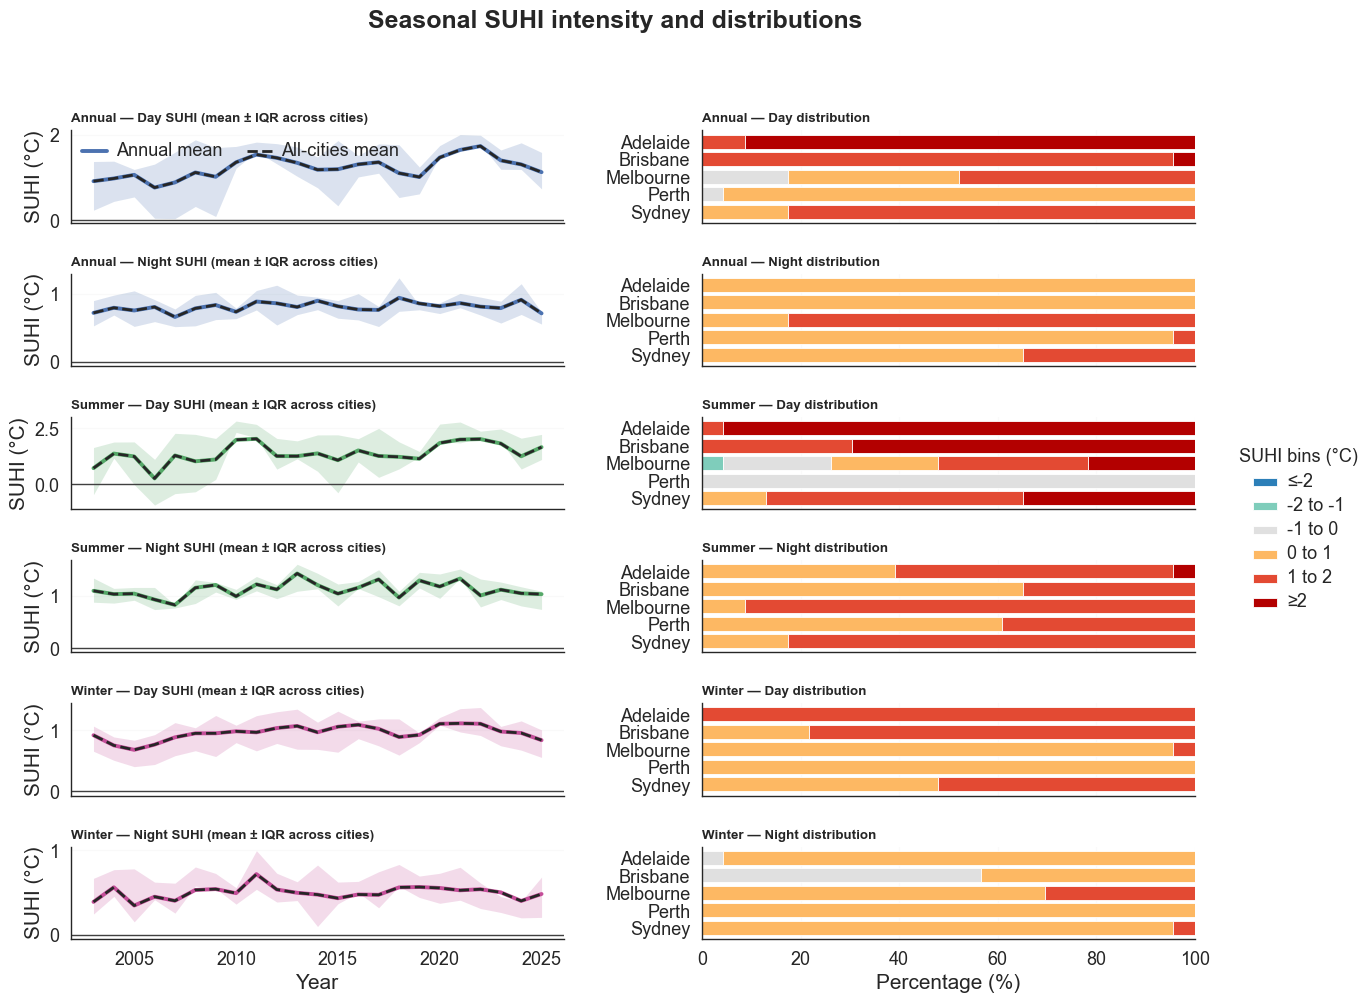

In [16]:
# MAIN Fig 0 — Seasonal SUHI intensity + distributions (Day & Night) ---
# Saves PNG/PDF/SVG to FIG_MAIN.

from matplotlib.gridspec import GridSpec
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="paper")

# Ensure FIG_MAIN exists
try:
    FIG_MAIN
except NameError:
    FIG_MAIN = Path("figures_main")
FIG_MAIN = Path(FIG_MAIN)
FIG_MAIN.mkdir(parents=True, exist_ok=True)

def save_fig(fig, outdir, name, dpi=400):
    """Save figure as PNG+PDF+SVG to outdir/name.*"""
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    apply_large_figure_text(fig)
    fig.savefig(outdir / f"{name}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(outdir / f"{name}.pdf", bbox_inches="tight")
    apply_large_figure_text(fig)
    fig.savefig(outdir / f"{name}.svg", bbox_inches="tight")
    print("Saved:", outdir / f"{name}.png")

def main_fig0_overview_intensity_distribution(panel, name="MainFig0_SUHI_Overview_Intensity_Distribution"):
    d = panel.copy()

    # Expect 'season' in {"Annual","Summer","Winter"} and columns YDAY/YNIGHT
    seasons = ["Annual", "Summer", "Winter"]
    cities = sorted(d["city"].dropna().astype(str).unique())

    # bins for SUHI distribution (% of years)
    bins   = [-10, -2, -1, 0, 1, 2, 10]
    labels = ["≤-2", "-2 to -1", "-1 to 0", "0 to 1", "1 to 2", "≥2"]

    # diverging-ish palette (negative->neutral->positive)
    pal = ["#2C7FB8", "#7FCDBB", "#E0E0E0", "#FDB863", "#E34A33", "#B30000"]
    bin_colors = dict(zip(labels, pal))

    season_colors = {"Annual": "#4C72B0", "Summer": "#55A868", "Winter": "#C44E99"}

    # ---- helpers ----
    def mean_iqr(df, ycol):
        g = df.dropna(subset=[ycol]).groupby("year")[ycol]
        if g.ngroups == 0:
            return pd.DataFrame(columns=["year","mean","q25","q75"])
        return pd.DataFrame({
            "year": g.mean().index.values,
            "mean": g.mean().values,
            "q25": g.quantile(0.25).values,
            "q75": g.quantile(0.75).values
        }).sort_values("year")

    def all_city_mean(df, ycol):
        out = df.dropna(subset=[ycol]).groupby("year")[ycol].mean().reset_index(name="mu")
        return out.sort_values("year")

    def dist_pct(df, ycol):
        tmp = df.dropna(subset=[ycol, "city"]).copy()
        tmp["city"] = tmp["city"].astype(str)
        # assign bins
        tmp["bin"] = pd.cut(tmp[ycol], bins=bins, labels=labels, include_lowest=True)
        cnt = (tmp.groupby(["city","bin"], observed=True)
                 .size().reset_index(name="n"))
        if cnt.empty:
            return pd.DataFrame(0.0, index=cities, columns=labels)
        cnt["pct"] = 100 * cnt["n"] / cnt.groupby("city", observed=True)["n"].transform("sum")

        piv = (cnt.pivot(index="city", columns="bin", values="pct")
                  .reindex(index=cities, columns=labels)
                  .fillna(0.0))
        return piv

    # ---- figure layout ----
    fig = plt.figure(figsize=(14.5, 10.5))
    gs = GridSpec(6, 2, figure=fig, hspace=0.55, wspace=0.28)

    legend_handles = None  # store once (from first distribution plot)

    for i, season in enumerate(seasons):
        ds = d[d["season"] == season].copy()

        # ===== Day intensity =====
        ax = fig.add_subplot(gs[2*i, 0])
        mi = mean_iqr(ds, YDAY)
        mu = all_city_mean(ds, YDAY)

        if not mi.empty:
            ax.fill_between(mi["year"], mi["q25"], mi["q75"],
                            color=season_colors[season], alpha=0.20, linewidth=0)
            ax.plot(mi["year"], mi["mean"], color=season_colors[season], lw=2.8, label=f"{season} mean")
        if not mu.empty:
            ax.plot(mu["year"], mu["mu"], color="0.15", lw=2.0, ls="--", label="All-cities mean")

        ax.axhline(0, color="0.25", lw=1)
        ax.grid(axis="y", color="0.92", lw=0.8)
        sns.despine(ax=ax)
        ax.set_title(f"{season} — Day SUHI (mean ± IQR across cities)", loc="left", fontweight="bold")
        ax.set_ylabel("SUHI (°C)")
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

        if i == 0:
            ax.legend(loc="upper left", ncol=2, frameon=False)

        # ===== Day distribution (stacked % by bins) =====
        axd = fig.add_subplot(gs[2*i, 1])
        piv = dist_pct(ds, YDAY)

        left = np.zeros(len(piv))
        handles = []
        for lab in labels:
            bars = axd.barh(piv.index, piv[lab].values, left=left,
                            color=bin_colors[lab], edgecolor="white", linewidth=0.6)
            left += piv[lab].values
            if len(bars) > 0:
                handles.append(bars[0])

        axd.set_xlim(0, 100)
        axd.set_title(f"{season} — Day distribution", loc="left", fontweight="bold")
        axd.grid(axis="x", color="0.93", lw=0.8)
        sns.despine(ax=axd)
        axd.invert_yaxis()
        axd.set_xlabel("")
        axd.tick_params(axis="x", labelbottom=False)

        if legend_handles is None:
            legend_handles = handles

        # ===== Night intensity =====
        ax2 = fig.add_subplot(gs[2*i+1, 0])
        mi2 = mean_iqr(ds, YNIGHT)
        mu2 = all_city_mean(ds, YNIGHT)

        if not mi2.empty:
            ax2.fill_between(mi2["year"], mi2["q25"], mi2["q75"],
                             color=season_colors[season], alpha=0.20, linewidth=0)
            ax2.plot(mi2["year"], mi2["mean"], color=season_colors[season], lw=2.8)
        if not mu2.empty:
            ax2.plot(mu2["year"], mu2["mu"], color="0.15", lw=2.0, ls="--")

        ax2.axhline(0, color="0.25", lw=1)
        ax2.grid(axis="y", color="0.92", lw=0.8)
        sns.despine(ax=ax2)
        ax2.set_title(f"{season} — Night SUHI (mean ± IQR across cities)", loc="left", fontweight="bold")
        ax2.set_ylabel("SUHI (°C)")
        ax2.set_xlabel("Year" if i==len(seasons)-1 else "")
        ax2.tick_params(axis="x", labelbottom=(i==len(seasons)-1))

        # ===== Night distribution =====
        ax2d = fig.add_subplot(gs[2*i+1, 1])
        piv2 = dist_pct(ds, YNIGHT)

        left = np.zeros(len(piv2))
        for lab in labels:
            ax2d.barh(piv2.index, piv2[lab].values, left=left,
                      color=bin_colors[lab], edgecolor="white", linewidth=0.6)
            left += piv2[lab].values

        ax2d.set_xlim(0, 100)
        ax2d.set_title(f"{season} — Night distribution", loc="left", fontweight="bold")
        ax2d.grid(axis="x", color="0.93", lw=0.8)
        sns.despine(ax=ax2d)
        ax2d.invert_yaxis()
        ax2d.set_xlabel("Percentage (%)" if i==len(seasons)-1 else "")
        ax2d.tick_params(axis="x", labelbottom=(i==len(seasons)-1))

    # ---- legend + title + save ----
    if legend_handles is not None:
        fig.legend(legend_handles, labels, title="SUHI bins (°C)",
                   loc="center right", bbox_to_anchor=(1.02, 0.5), frameon=False)

    fig.suptitle("Seasonal SUHI intensity and distributions", y=0.995, fontweight="bold")
    save_fig(fig, FIG_MAIN, name)
    plt.show()

# Run
main_fig0_overview_intensity_distribution(panel)

## Fig 2 — Temporal evolution and trends
City-fixed-effects trend (β °C/year) shown in each panel.


C:\Users\momu1064\AppData\Local\Temp\ipykernel_23832\1666591675.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tr = tmp.groupby("city").apply(slope_per_decade).rename("slope_decC").reset_index()
C:\Users\momu1064\AppData\Local\Temp\ipykernel_23832\1666591675.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tr = tmp.groupby("city").apply(slope_per_decade).rename("slope_decC").reset_index()
C:\Users\momu1064\

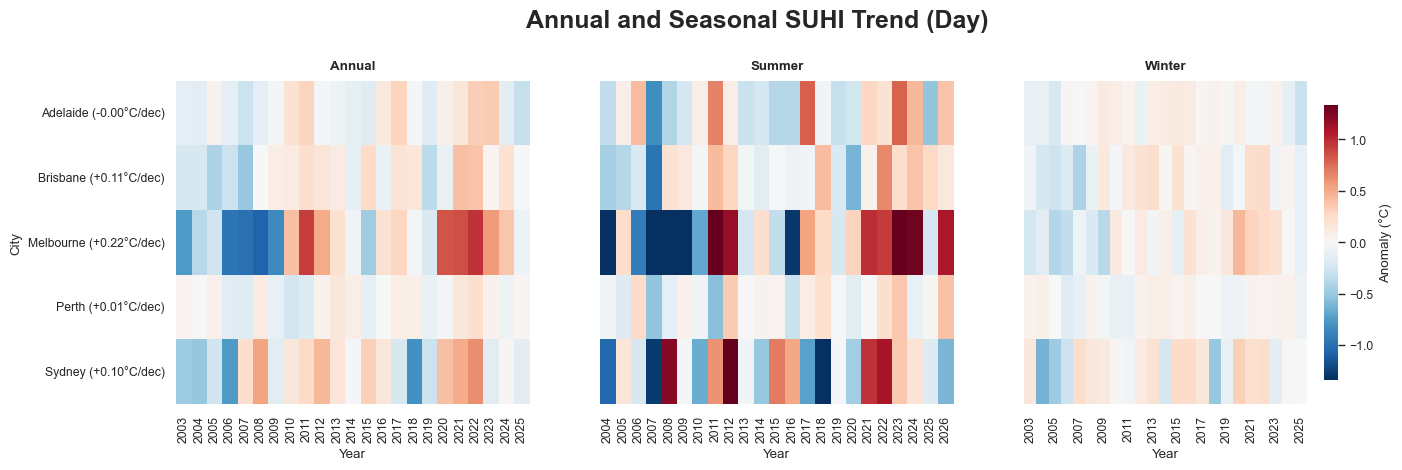

Saved: paper_outputs_final\figures_main\MainFig1_Fingerprint_Day.(png/pdf/svg)


C:\Users\momu1064\AppData\Local\Temp\ipykernel_23832\1666591675.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tr = tmp.groupby("city").apply(slope_per_decade).rename("slope_decC").reset_index()
C:\Users\momu1064\AppData\Local\Temp\ipykernel_23832\1666591675.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tr = tmp.groupby("city").apply(slope_per_decade).rename("slope_decC").reset_index()
C:\Users\momu1064\

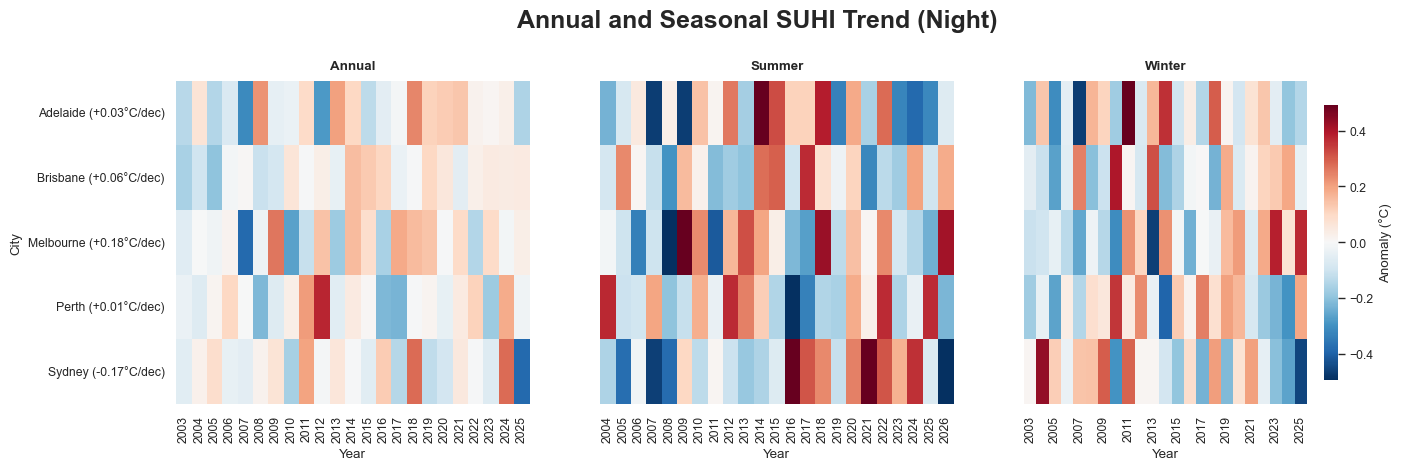

Saved: paper_outputs_final\figures_main\MainFig1_Fingerprint_Night.(png/pdf/svg)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="paper")

def main_fig1_city_year_fingerprint(panel, ycol, tod_label, name_prefix="MainFig1_CityYearFingerprint"):
    """
    City (rows) × year (cols) heatmaps for Annual/Summer/Winter, for a single outcome ycol (Day or Night).
    Values are anomalies (city-mean removed within each season).
    City labels include linear trend (°C/decade) for that season.
    """
    seasons = ["Annual","Summer","Winter"]

    def slope_per_decade(x):
        if x["year"].nunique() < 5:
            return np.nan
        yy = x["y"].values
        tt = x["year"].values
        b = np.polyfit(tt, yy, 1)[0]  # °C/year
        return 10*b

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2), sharey=True)
    vlim = None
    vals=[]
    for season in seasons:
        ds = panel[panel["season"]==season].dropna(subset=[ycol]).copy()
        if ds.empty: 
            continue
        # anomalies per city
        ds["anom"] = ds[ycol] - ds.groupby("city")[ycol].transform("mean")
        vals.append(ds["anom"].values)
    if vals:
        vv = np.concatenate(vals)
        vlim = np.nanpercentile(np.abs(vv), 98)  # robust scaling
    else:
        vlim = 1.0

    for j, season in enumerate(seasons):
        ax = axes[j]
        ds = panel[panel["season"]==season].dropna(subset=[ycol]).copy()
        if ds.empty:
            ax.axis("off")
            ax.set_title(season, fontweight="bold")
            continue

        # trends for labels
        tmp = ds.rename(columns={ycol:"y"}).copy()
        tr = tmp.groupby("city").apply(slope_per_decade).rename("slope_decC").reset_index()
        tr["slope_decC"] = tr["slope_decC"].astype(float)

        # anomalies
        ds["anom"] = ds[ycol] - ds.groupby("city")[ycol].transform("mean")

        mat = ds.pivot_table(index="city", columns="year", values="anom", aggfunc="mean")
        # order cities alphabetically
        cities = sorted(mat.index.tolist())
        mat = mat.reindex(cities)

        # label with slope
        tr = tr.set_index("city").reindex(cities)
        ylabels = [f"{c} ({tr.loc[c,'slope_decC']:+.02f}°C/dec)" if pd.notnull(tr.loc[c,'slope_decC']) else c for c in cities]

        sns.heatmap(mat, ax=ax, cmap="RdBu_r", center=0, vmin=-vlim, vmax=vlim,
                    cbar=(j==2), cbar_kws={"shrink":0.85, "label":"Anomaly (°C)"})
        ax.set_title(season, y=1.01, fontweight="bold")
        ax.set_xlabel("Year")
        if j==0:
            ax.set_ylabel("City")
        else:
            ax.set_ylabel("")
        ax.set_yticklabels(ylabels, rotation=0)

    fig.suptitle(f"Annual and Seasonal SUHI Trend ({tod_label})", y=1.05, fontsize=18,fontweight="bold")
    plt.show()
    fig.tight_layout()
    outbase = FIG_MAIN / f"{name_prefix}_{tod_label}"
    save_fig_multi(fig, outbase, close=True)
    print("Saved:", str(outbase)+".(png/pdf/svg)")

# --- Generate BOTH Day and Night fingerprints ---
if 'panel' in globals():
    if YDAY in panel.columns:
        main_fig1_city_year_fingerprint(panel, YDAY, "Day", name_prefix="MainFig1_Fingerprint")
    if YNIGHT in panel.columns:
        main_fig1_city_year_fingerprint(panel, YNIGHT, "Night", name_prefix="MainFig1_Fingerprint")

## Fig 3 — Distribution shifts (Early vs Late)
KDE comparison of SUHI distributions for early vs late years.


Saved: paper_outputs_final\figures_main\MainFig2_DistributionShift.png


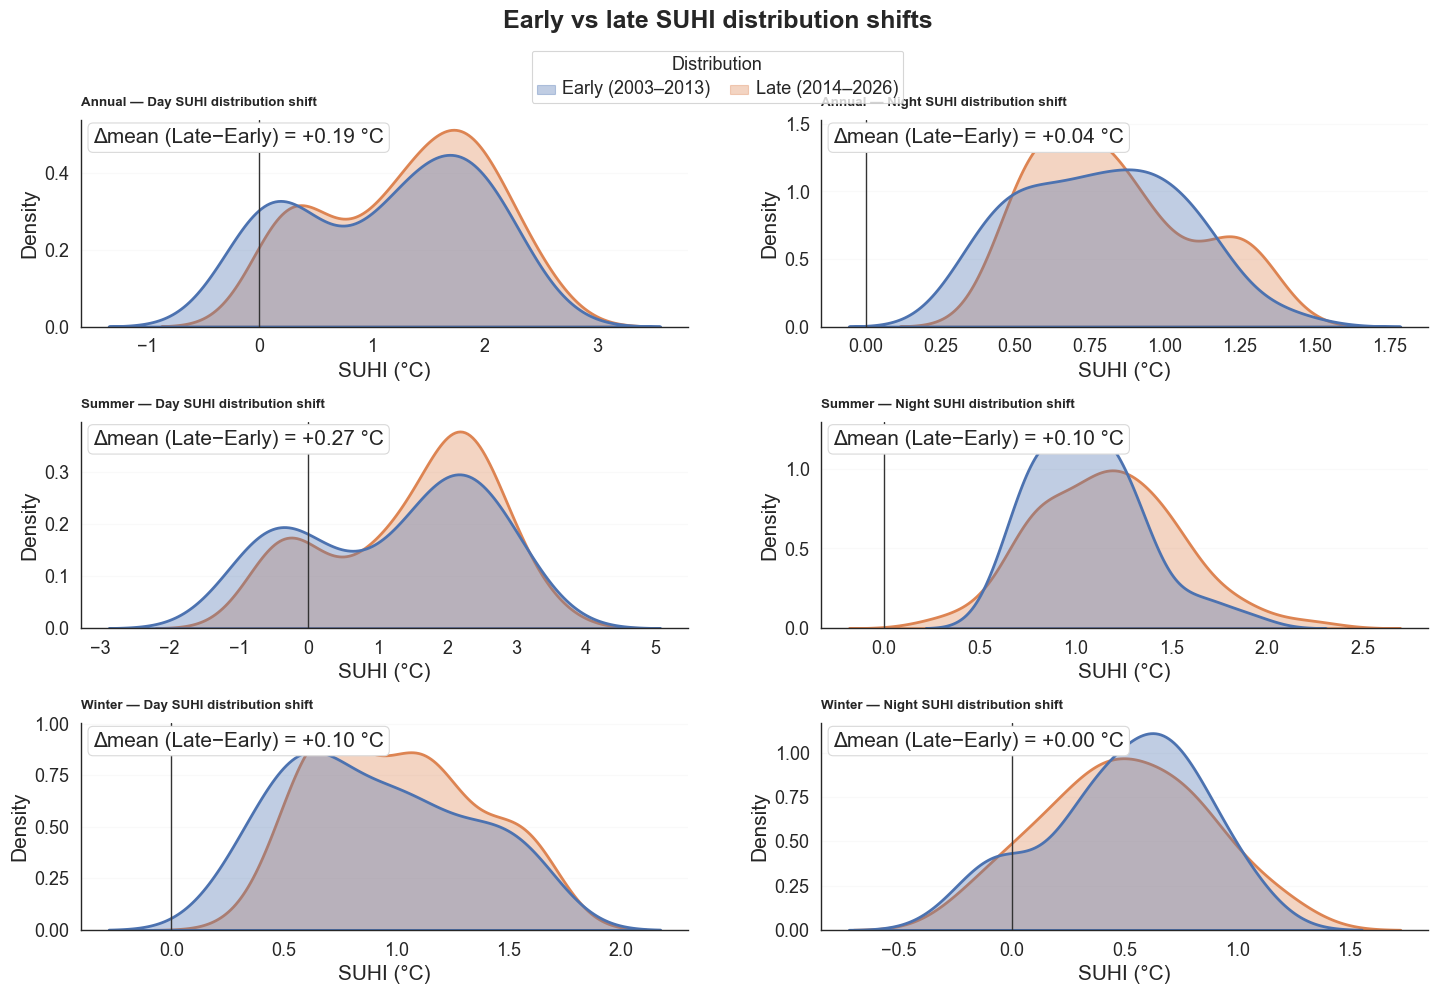

In [18]:

if MAKE_SUPP_PLOTS:
    # ---Distribution shift (KDE) ---

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from pathlib import Path
    from matplotlib.gridspec import GridSpec
    from matplotlib.patches import Patch

    try:
        FIG_MAIN
    except NameError:
        FIG_MAIN = Path("figures_main")
    FIG_MAIN = Path(FIG_MAIN)
    FIG_MAIN.mkdir(parents=True, exist_ok=True)

    def save_fig(fig, outdir, name, dpi=400):
        """Save figure as PNG+PDF+SVG to outdir/name.*"""
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        apply_large_figure_text(fig)
        fig.savefig(outdir / f"{name}.png", dpi=dpi, bbox_inches="tight")
        fig.savefig(outdir / f"{name}.pdf", bbox_inches="tight")
        apply_large_figure_text(fig)
        fig.savefig(outdir / f"{name}.svg", bbox_inches="tight")
        print("Saved:", outdir / f"{name}.png")

    def main_fig2_distribution_shift(panel, split_year=2014, name="MainFig2_DistributionShift"):
        """
        Compare early vs late SUHI distributions (KDE) for Day/Night and each season.
        Requires globals: YDAY, YNIGHT.
        """
        seasons = ["Annual", "Summer", "Winter"]
        fig = plt.figure(figsize=(14.8, 10.0))
        gs = GridSpec(3, 2, figure=fig, hspace=0.46, wspace=0.22)

        year_min = int(np.nanmin(panel["year"]))
        year_max = int(np.nanmax(panel["year"]))
        early_label = f"Early ({year_min}–{split_year-1})"
        late_label = f"Late ({split_year}–{year_max})"
        pal = {early_label: "#4c72b0", late_label: "#dd8452"}
        legend_handles = [
            Patch(facecolor=pal[early_label], edgecolor=pal[early_label], alpha=0.35, label=early_label),
            Patch(facecolor=pal[late_label], edgecolor=pal[late_label], alpha=0.35, label=late_label),
        ]

        for i, season in enumerate(seasons):
            ds = panel[panel["season"] == season].copy()

            ds["Distribution"] = np.where(
                ds["year"] < split_year,
                early_label,
                late_label
            )

            for j, (ycol, title2) in enumerate([(YDAY, "Day"), (YNIGHT, "Night")]):
                ax = fig.add_subplot(gs[i, j])
                dd = ds.dropna(subset=[ycol]).copy()

                if dd.empty:
                    ax.axis("off")
                    ax.text(0.5, 0.5, "No data", ha="center", va="center")
                    continue

                sns.kdeplot(
                    data=dd, x=ycol, hue="Distribution",
                    fill=True, common_norm=False, alpha=0.35, lw=2, ax=ax,
                    palette=pal, legend=False
                )

                mu_early = dd.loc[dd["Distribution"] == early_label, ycol].mean()
                mu_late  = dd.loc[dd["Distribution"] == late_label, ycol].mean()

                ax.text(
                    0.02, 0.96,
                    f"Δmean (Late−Early) = {mu_late - mu_early:+.2f} °C",
                    transform=ax.transAxes, va="top", ha="left",
                    fontsize=15, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.85")
                )

                ax.axvline(0, color="0.2", lw=1)
                ax.grid(axis="y", color="0.92", lw=0.8)
                sns.despine(ax=ax)
                ax.set_title(f"{season} — {title2} SUHI distribution shift", loc="left", fontweight="bold", pad=10)
                ax.set_ylabel("Density")
                ax.set_xlabel("SUHI (°C)")

        fig.suptitle("Early vs late SUHI distribution shifts", y=0.99, fontweight="bold")
        fig.legend(
            handles=legend_handles, labels=[early_label, late_label], title="Distribution",
            loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=2,
            frameon=True, handlelength=1.5, handletextpad=0.6, columnspacing=1.6
        )
        fig.subplots_adjust(top=0.88, bottom=0.07, left=0.07, right=0.98, hspace=0.46, wspace=0.22)
        save_fig(fig, FIG_MAIN, name)
        plt.show()

    # Run
    main_fig2_distribution_shift(panel, split_year=2014)


## Fig 4 — Partial relationships
Residual–residual plots after removing controls + city/year fixed effects.


Saved: paper_outputs_final\figures_main\MainFig3_PartialRelationships.png


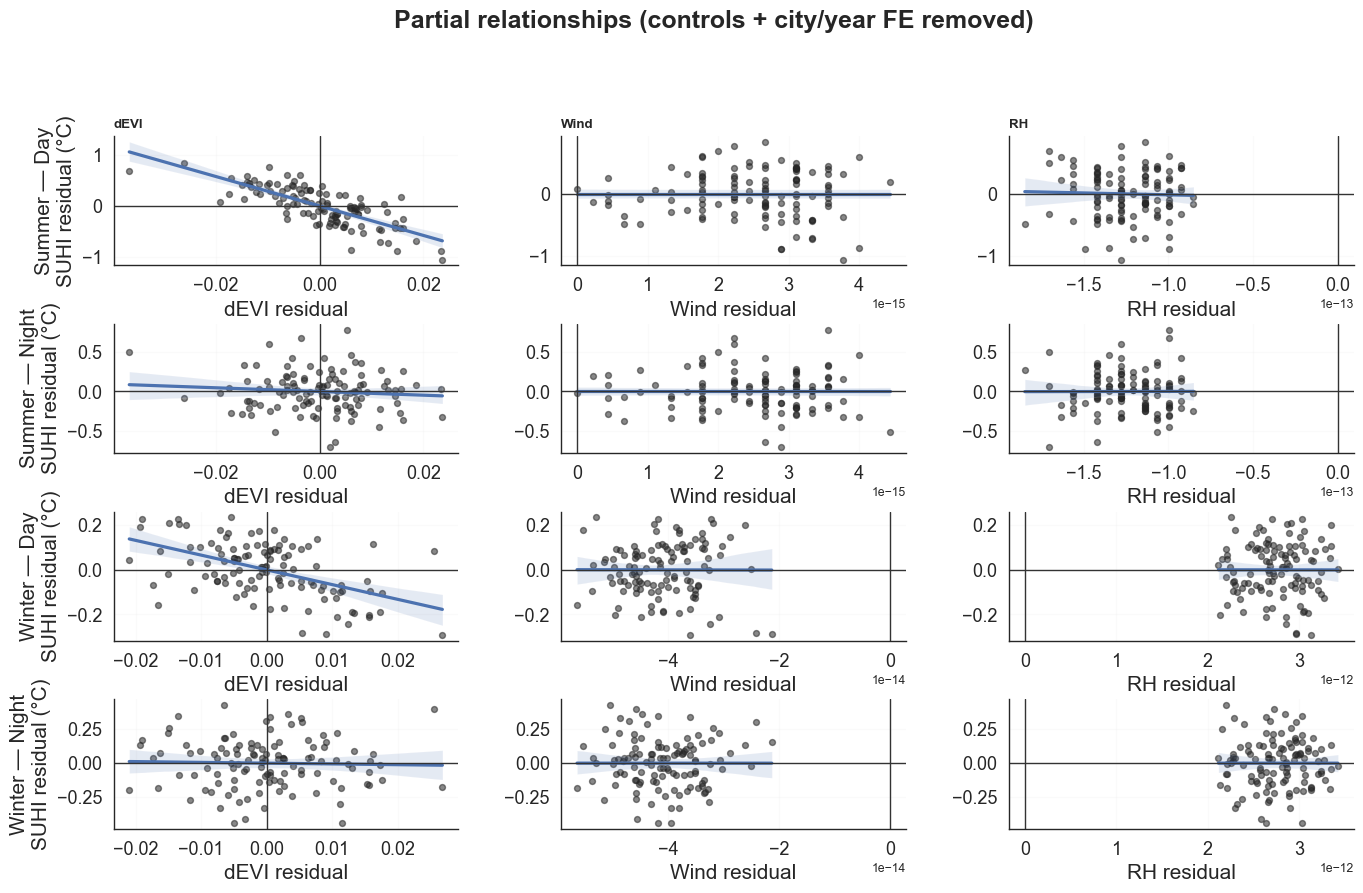

In [19]:

import statsmodels.formula.api as smf

CTRL = ["wind10_ms_mean", "rh_pct_mean", "cloud_frac_mean", "blh_m_mean"]

def partial_out(df, y, x, controls):
    d = df.dropna(subset=[y, x] + controls + ["city","year"]).copy()

    y_mod = smf.ols(
        f"{y} ~ " + " + ".join(controls) + " + C(city) + C(year)",
        data=d
    ).fit()

    x_mod = smf.ols(
        f"{x} ~ " + " + ".join(controls) + " + C(city) + C(year)",
        data=d
    ).fit()

    outp = d[["city","year","season"]].copy()
    outp["x_res"] = x_mod.resid
    outp["y_res"] = y_mod.resid
    return outp

drivers = ["dEVI_mean", "wind10_ms_mean", "rh_pct_mean"]
driver_labels = {v: pretty_driver(v) for v in drivers}

def main_fig3_partial(panel, name="MainFig3_PartialRelationships"):
    fig = plt.figure(figsize=(16, 9))
    gs = GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.30)

    row_specs = [
        ("Summer", "Day",   YDAY),
        ("Summer", "Night", YNIGHT),
        ("Winter", "Day",   YDAY),
        ("Winter", "Night", YNIGHT),
    ]

    for r, (season, tod, ycol) in enumerate(row_specs):
        ds = panel[panel["season"] == season].copy()

        for c, xcol in enumerate(drivers):
            ax = fig.add_subplot(gs[r, c])
            pr = partial_out(ds, y=ycol, x=xcol, controls=CTRL)

            sns.regplot(
                data=pr, x="x_res", y="y_res", ax=ax,
                scatter_kws=dict(s=18, alpha=0.55, color="0.15"),
                line_kws=dict(lw=2.3),
                ci=95
            )

            ax.axhline(0, lw=1, color="0.2")
            ax.axvline(0, lw=1, color="0.2")
            ax.grid(color="0.93", lw=0.8)
            sns.despine(ax=ax)

            ax.set_xlabel(f"{driver_labels[xcol]} residual")

            if c == 0:
                ax.set_ylabel(f"{season} — {tod}\nSUHI residual (°C)")
            else:
                ax.set_ylabel("")

            if r == 0:
                ax.set_title(driver_labels[xcol], loc="left", fontweight="bold")

    fig.suptitle("Partial relationships (controls + city/year FE removed)", y=1.02, fontweight="bold")
    save_fig(fig, FIG_MAIN, name)
    plt.show()

main_fig3_partial(panel)


## MAIN Fig 5 — Urban vs rural LST (context) and SUHI–urban LST relationships

Saved: paper_outputs_final\figures_main\MainFig5A_UrbanRuralLST_TimeSeries_AllSeasons.png


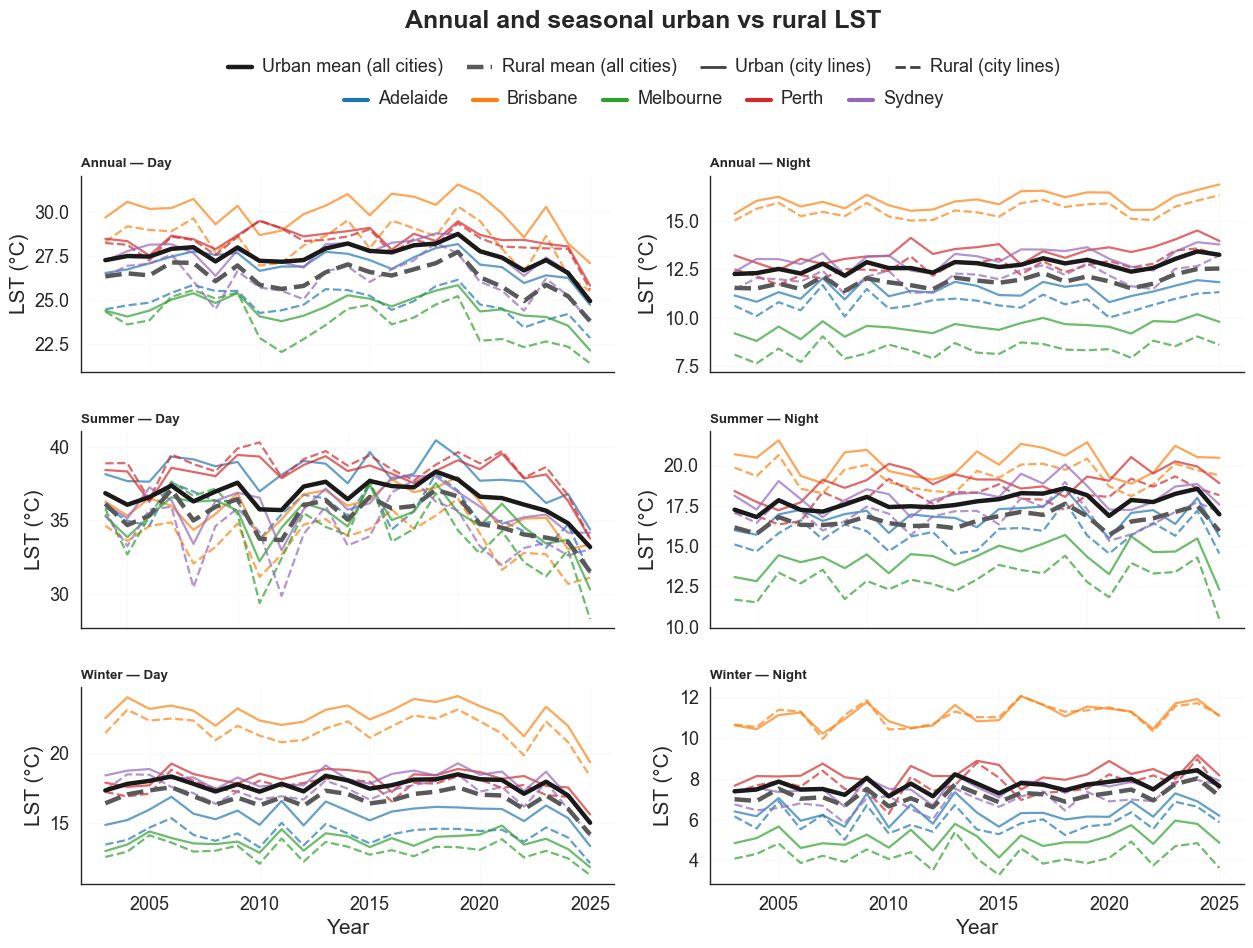

Saved: paper_outputs_final\figures_main\MainFig5B_SUHI_vs_UrbanLST_AllSeasons_DayNight.png


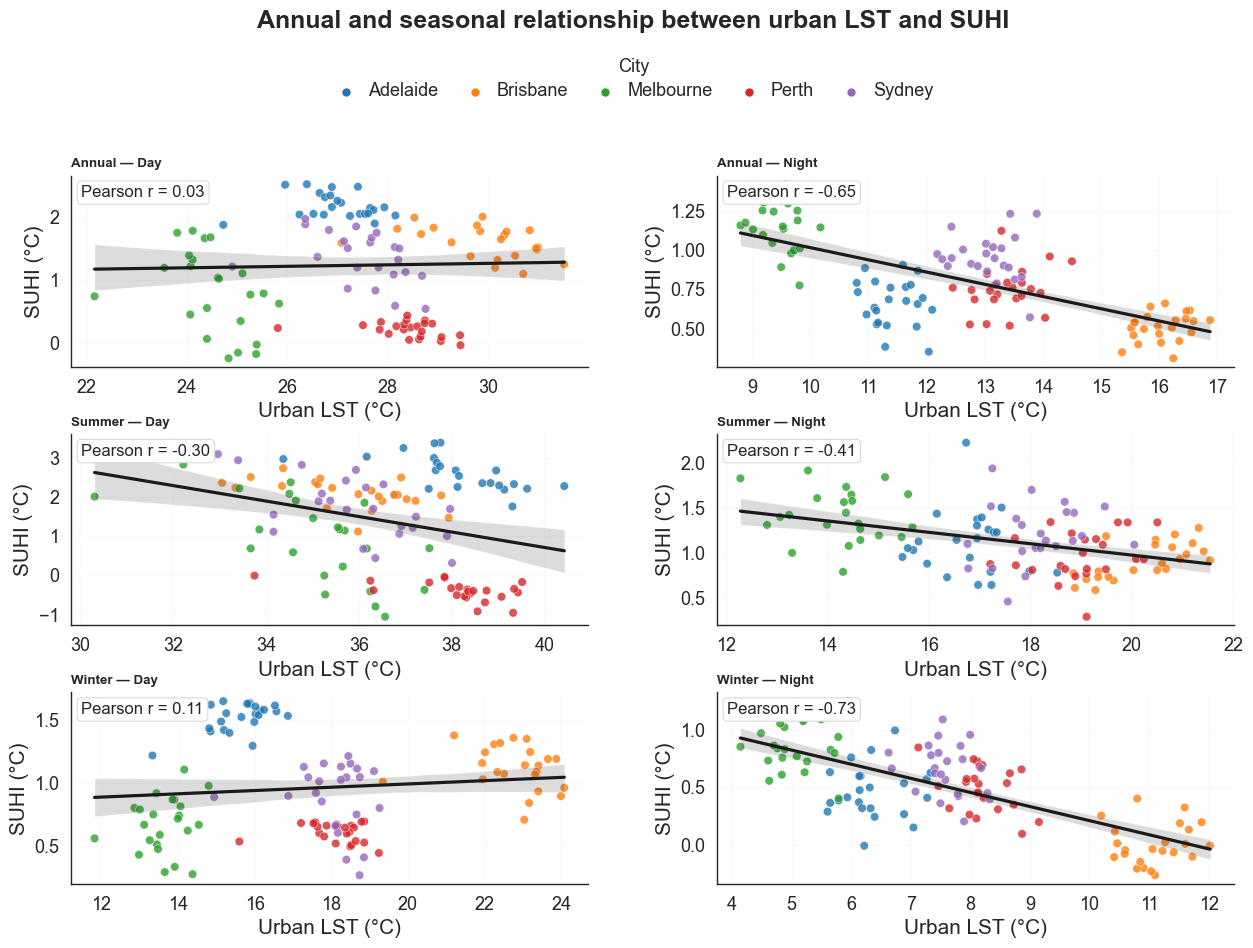

In [20]:
# ---  MAIN Fig 5A + 5B  ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set_theme(style="white", context="paper")

# --- Require aggregated urban/rural LST means ---
needed = ["urban_lst_day_C_mean","urban_lst_night_C_mean","rural_lst_day_C_mean","rural_lst_night_C_mean"]
have = [c for c in needed if c in panel.columns]

if len(have) < len(needed):
    print("Urban/rural LST columns not found in `panel` (skipping MAIN Fig 5).")
    print("Expected columns:", needed)
    print("Available columns containing 'lst':", [c for c in panel.columns if "lst" in c.lower()])

else:
    # =========================================================
    # (A) Fig 5A
    # =========================================================
    cities = sorted(panel["city"].dropna().astype(str).unique())
    palette = dict(zip(cities, sns.color_palette("tab10", n_colors=len(cities))))

    fig = plt.figure(figsize=(15, 9.2))
    gs = fig.add_gridspec(3, 2, hspace=0.30, wspace=0.18)

    def plot_ur(ax, season, tod, ucol, rcol):
        ds = panel[panel["season"] == season].copy()

        # plot each city: urban solid, rural dashed, same color
        for city in cities:
            dd = ds[ds["city"].astype(str) == city].sort_values("year")
            if dd.empty:
                continue
            ax.plot(dd["year"], dd[ucol], lw=1.6, alpha=0.70, color=palette[city], linestyle="-")
            ax.plot(dd["year"], dd[rcol], lw=1.6, alpha=0.70, color=palette[city], linestyle="--")

        # all-cities mean
        mu_u = ds.groupby("year")[ucol].mean().reset_index()
        mu_r = ds.groupby("year")[rcol].mean().reset_index()
        ax.plot(mu_u["year"], mu_u[ucol], lw=3.2, color="0.10", linestyle="-", label="Urban mean (all cities)")
        ax.plot(mu_r["year"], mu_r[rcol], lw=3.2, color="0.35", linestyle="--", label="Rural mean (all cities)")

        ax.set_title(f"{season} — {tod}", loc="left", fontweight="bold")
        ax.set_ylabel("LST (°C)")
        ax.grid(color="0.93", lw=0.8)
        sns.despine(ax=ax)

    for i, season in enumerate(["Annual", "Summer", "Winter"]):
        axd = fig.add_subplot(gs[i, 0])
        axn = fig.add_subplot(gs[i, 1])

        plot_ur(axd, season, "Day",   "urban_lst_day_C_mean",   "rural_lst_day_C_mean")
        plot_ur(axn, season, "Night", "urban_lst_night_C_mean", "rural_lst_night_C_mean")

        if i < 2:
            axd.set_xlabel("")
            axn.set_xlabel("")
            axd.tick_params(axis="x", labelbottom=False)
            axn.tick_params(axis="x", labelbottom=False)
        else:
            axd.set_xlabel("Year")
            axn.set_xlabel("Year")

    # --- Legend 1: Urban vs Rural meaning (line styles) + all-city means ---
    style_handles = [
        plt.Line2D([0],[0], color="0.10", lw=3.2, linestyle="-",  label="Urban mean (all cities)"),
        plt.Line2D([0],[0], color="0.35", lw=3.2, linestyle="--", label="Rural mean (all cities)"),
        plt.Line2D([0],[0], color="0.25", lw=2.0, linestyle="-",  label="Urban (city lines)"),
        plt.Line2D([0],[0], color="0.25", lw=2.0, linestyle="--", label="Rural (city lines)"),
    ]

    fig.legend(handles=style_handles, loc="upper center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, 1.02))

    # --- Legend 2: City colors ---
    city_handles = [plt.Line2D([0],[0], color=palette[c], lw=3.0, label=c) for c in cities]
    fig.legend(handles=city_handles, loc="upper center", ncol=min(6, len(cities)), frameon=False,
               bbox_to_anchor=(0.5, 0.985))

    fig.suptitle("Annual and seasonal urban vs rural LST", y=1.06, fontweight="bold")

    save_fig(fig, FIG_MAIN, "MainFig5A_UrbanRuralLST_TimeSeries_AllSeasons")
    plt.show()

    # =========================================================
    # (B) Fig 5B 
    # =========================================================
    rows = []
    for season in ["Annual", "Summer", "Winter"]:
        ds = panel[panel["season"] == season].copy()
        for tod, suhi_col, urb_col in [
            ("Day",   "suhi_day_C_mean",   "urban_lst_day_C_mean"),
            ("Night", "suhi_night_C_mean", "urban_lst_night_C_mean"),
        ]:
            dd = ds.dropna(subset=[suhi_col, urb_col, "city", "year"]).copy()
            dd["time"] = tod
            dd["suhi"] = dd[suhi_col]
            dd["urban_lst"] = dd[urb_col]
            dd["season"] = season
            dd["city"] = dd["city"].astype(str)
            rows.append(dd[["city", "year", "season", "time", "suhi", "urban_lst"]])

    long = pd.concat(rows, ignore_index=True)

    fig = plt.figure(figsize=(15, 9.2))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

    for i, season in enumerate(["Annual", "Summer", "Winter"]):
        for j, tod in enumerate(["Day", "Night"]):
            ax = fig.add_subplot(gs[i, j])
            dd = long[(long["season"] == season) & (long["time"] == tod)].copy()

            if dd.empty:
                ax.axis("off")
                ax.text(0.5, 0.5, "No data", ha="center", va="center")
                continue

            sns.scatterplot(
                data=dd, x="urban_lst", y="suhi",
                hue="city", palette=palette,
                ax=ax, s=38, alpha=0.80, edgecolor="white", linewidth=0.4,
                legend=True
            )

            sns.regplot(
                data=dd, x="urban_lst", y="suhi",
                ax=ax, scatter=False, ci=95,
                line_kws=dict(lw=2.3, color="0.10")
            )

            r = np.nan
            if len(dd) >= 10:
                r, _ = pearsonr(dd["urban_lst"], dd["suhi"])
            ax.text(
                0.02, 0.95, f"Pearson r = {r:.2f}" if pd.notna(r) else "Pearson r = NA",
                transform=ax.transAxes, va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.85")
            )

            ax.set_title(f"{season} — {tod}", loc="left", fontweight="bold")
            ax.set_xlabel("Urban LST (°C)")
            ax.set_ylabel("SUHI (°C)")
            ax.grid(color="0.93", lw=0.8)
            sns.despine(ax=ax)
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()
    city_handles = [
        plt.Line2D([0],[0], marker="o", linestyle="", markersize=7,
                   markerfacecolor=palette[c], markeredgecolor="white", label=c)
        for c in cities
    ]
    fig.legend(handles=city_handles, loc="upper center",
               ncol=min(6, len(cities)), frameon=False,
               bbox_to_anchor=(0.5, 1.02), title="City")

    fig.suptitle(
        "Annual and seasonal relationship between urban LST and SUHI",
        y=1.06, fontweight="bold"
    )

    save_fig(fig, FIG_MAIN, "MainFig5B_SUHI_vs_UrbanLST_AllSeasons_DayNight")
    plt.show()

## Fig 6 — Relative importance
Standardized effect sizes + incremental R² contributions.


Saved: paper_outputs_final\figures_main\MainFig4_MechanismCore_Option2.png


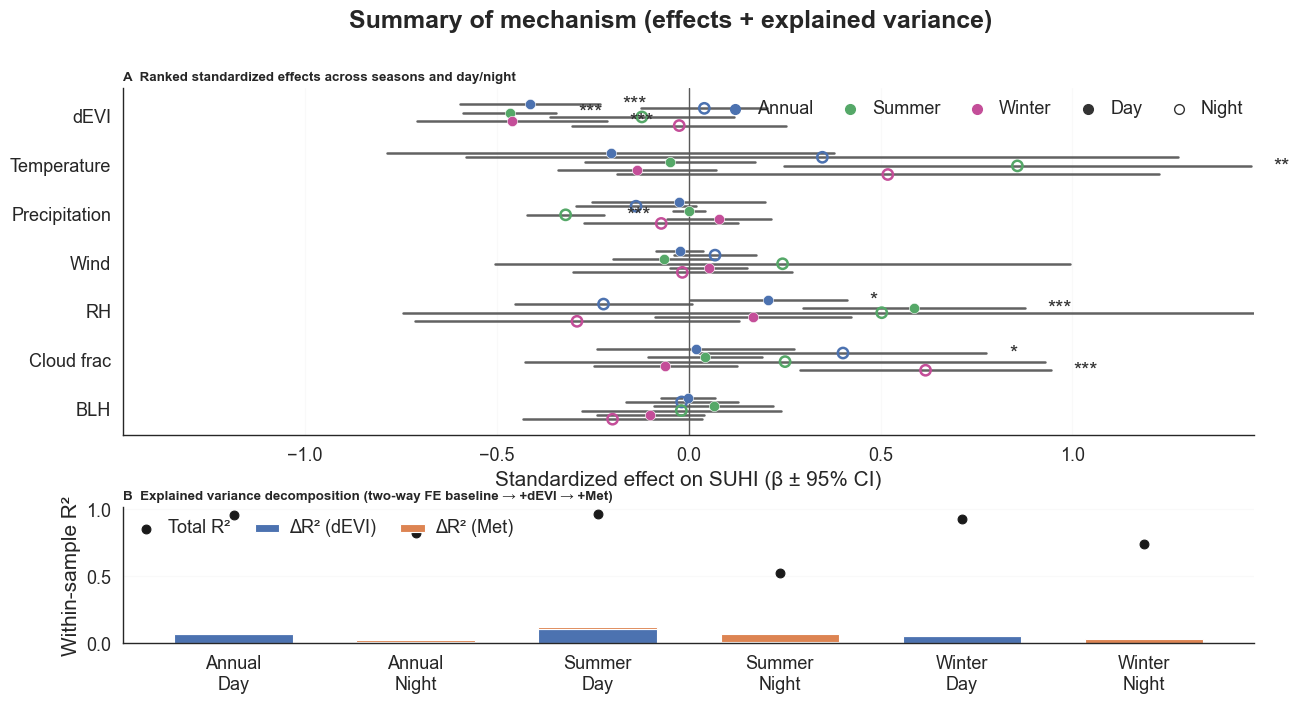

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --------- Drivers to show (in reading order; top-to-bottom in plot) ----------
DRIVER_ORDER = [v for v in [
    "dEVI_mean",
    "t2m_C_mean",
    "precip_mm_mean",
    "wind10_ms_mean",
    "rh_pct_mean",
    "cloud_frac_mean",
    "blh_m_mean",
] if v in panel.columns]

TERMS = [pretty_driver(v) for v in DRIVER_ORDER]

def _z(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / (s.std(ddof=0) + 1e-12)

def fit_std_betas(ds, ycol, xvars):
    d = ds.dropna(subset=[ycol] + xvars + ["city","year"]).copy()
    for v in [ycol] + xvars:
        d[v] = _z(d[v].astype(float))
    f = f"{ycol} ~ " + " + ".join(xvars) + " + C(city) + C(year)"
    m = smf.ols(f, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})
    rows=[]
    for v in xvars:
        b  = float(m.params.get(v, np.nan))
        se = float(m.bse.get(v, np.nan))
        lo, hi = b - 1.96*se, b + 1.96*se
        p  = float(m.pvalues.get(v, np.nan))
        rows.append({"var": v, "beta": b, "lo": lo, "hi": hi, "p": p})
    return pd.DataFrame(rows)

def r2_decomp(ds, ycol, evi="dEVI_mean",
             met=("t2m_C_mean","precip_mm_mean","wind10_ms_mean","rh_pct_mean","cloud_frac_mean","blh_m_mean")):
    met = [m for m in met if m in ds.columns and m != evi]
    need = [ycol, evi] + met + ["city","year"]
    d = ds.dropna(subset=need).copy()
    f0 = f"{ycol} ~ C(city) + C(year)"
    f1 = f"{ycol} ~ {evi} + C(city) + C(year)"
    f2 = f"{ycol} ~ {evi} + " + " + ".join(met) + " + C(city) + C(year)" if met else f1
    m0 = smf.ols(f0, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})
    m1 = smf.ols(f1, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})
    m2 = smf.ols(f2, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})
    r0, r1, r2 = float(m0.rsquared), float(m1.rsquared), float(m2.rsquared)
    return {"dR2_evi": max(0, r1-r0), "dR2_met": max(0, r2-r1), "r2_full": r2}

def stars(p):
    if not np.isfinite(p): return ""
    return "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""

def main_fig4_mechanism_core_option2(panel, name="MainFig4_MechanismCore_Option2"):
    seasons = ["Annual","Summer","Winter"]
    tods = [("Day", YDAY), ("Night", YNIGHT)]
    combos = [(s,t,y) for s in seasons for t,y in tods]
    combo_key = [f"{s}-{t}" for s,t,_ in combos]
    combo_label = [f"{s}\n{t}" for s,t,_ in combos]

    eff=[]
    r2=[]
    for (s,t,ycol) in combos:
        ds = panel[panel["season"]==s].copy()
        bet = fit_std_betas(ds, ycol, DRIVER_ORDER)
        bet["season"]=s; bet["tod"]=t
        bet["combo"]=f"{s}-{t}"
        bet["term"]=bet["var"].map(pretty_driver)
        eff.append(bet)

        rr = r2_decomp(ds, ycol=ycol)
        rr.update({"combo":f"{s}-{t}", "season":s, "tod":t})
        r2.append(rr)

    eff = pd.concat(eff, ignore_index=True)
    r2  = pd.DataFrame(r2).set_index("combo").reindex(combo_key).reset_index()

    # order drivers
    eff["term"] = pd.Categorical(eff["term"], TERMS, ordered=True)

    # robust xlim from CI range
    xmax = np.nanpercentile(np.abs(np.r_[eff["lo"].values, eff["hi"].values]), 98)
    xmax = float(max(0.35, xmax))
    xlim = (-1.10*xmax, 1.10*xmax)

    fig = plt.figure(figsize=(14.6, 7.2))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 1.25], hspace=0.30)

    # A) Effects
    axA = fig.add_subplot(gs[0,0])
    axA.axvline(0, color="0.35", lw=1.0)
    axA.grid(axis="x", color="0.92", lw=0.9)
    for spine in ["top","right"]:
        axA.spines[spine].set_visible(False)

    ybase = {term:i for i,term in enumerate(TERMS)}
    offsets = np.linspace(-0.22, 0.22, len(combo_key))

    season_palette = {"Annual":"#4C72B0", "Summer":"#55A868", "Winter":"#C44E99"}

    for k, ck in enumerate(combo_key):
        s, t = ck.split("-")
        sub = eff[eff["combo"]==ck].copy()
        for _, row in sub.iterrows():
            term = str(row["term"])
            y = ybase[term] + offsets[k]
            axA.plot([row["lo"], row["hi"]], [y, y], lw=1.8, color="0.35", alpha=0.95)
            col = season_palette[s]
            if t == "Night":
                axA.scatter(row["beta"], y, s=55, facecolors="none", edgecolors=col, linewidth=1.8, zorder=3)
            else:
                axA.scatter(row["beta"], y, s=55, color=col, edgecolors="white", linewidth=0.4, zorder=3)
            st = stars(row["p"])
            if st:
                axA.text(row["hi"] + 0.02*(xlim[1]-xlim[0]), y, st, va="center", fontsize=15, color="0.2")

    axA.set_yticks([ybase[t] for t in TERMS])
    axA.set_yticklabels(TERMS)
    axA.invert_yaxis()
    axA.set_xlim(*xlim)
    axA.set_xlabel("Standardized effect on SUHI (β ± 95% CI)")
    axA.set_title("A  Ranked standardized effects across seasons and day/night",
                  loc="left", fontweight="bold")

    season_handles = [plt.Line2D([0],[0], marker="o", linestyle="", color=season_palette[s], label=s, markersize=7)
                      for s in seasons]
    day_handle   = plt.Line2D([0],[0], marker="o", linestyle="", color="0.2", label="Day", markersize=7)
    night_handle = plt.Line2D([0],[0], marker="o", linestyle="", markerfacecolor="none",
                              markeredgecolor="0.2", color="0.2", label="Night", markersize=7)
    axA.legend(handles=season_handles + [day_handle, night_handle],
               frameon=False, ncol=5, loc="upper right")

    # B) ΔR² strip
    axB = fig.add_subplot(gs[1,0])
    x = np.arange(len(r2))
    axB.bar(x, r2["dR2_evi"], width=0.65, label="ΔR² (dEVI)")
    axB.bar(x, r2["dR2_met"], bottom=r2["dR2_evi"], width=0.65, label="ΔR² (Met)")
    axB.scatter(x, r2["r2_full"], s=40, color="0.1", zorder=3, label="Total R²")
    axB.set_xticks(x)
    axB.set_xticklabels(combo_label)
    axB.set_ylabel("Within-sample R²")
    axB.set_title("B  Explained variance decomposition (two-way FE baseline → +dEVI → +Met)",
                  loc="left", fontweight="bold")
    axB.grid(axis="y", color="0.92")
    for spine in ["top","right"]:
        axB.spines[spine].set_visible(False)
    axB.legend(frameon=False, ncol=3, loc="upper left")

    fig.suptitle("Summary of mechanism (effects + explained variance)", y=0.99, fontweight="bold")
    save_fig(fig, FIG_MAIN, name)
    plt.show()

main_fig4_mechanism_core_option2(panel)

## Supplementary figures and tables
Correlation structure, multicollinearity diagnostics, and full regression tables.


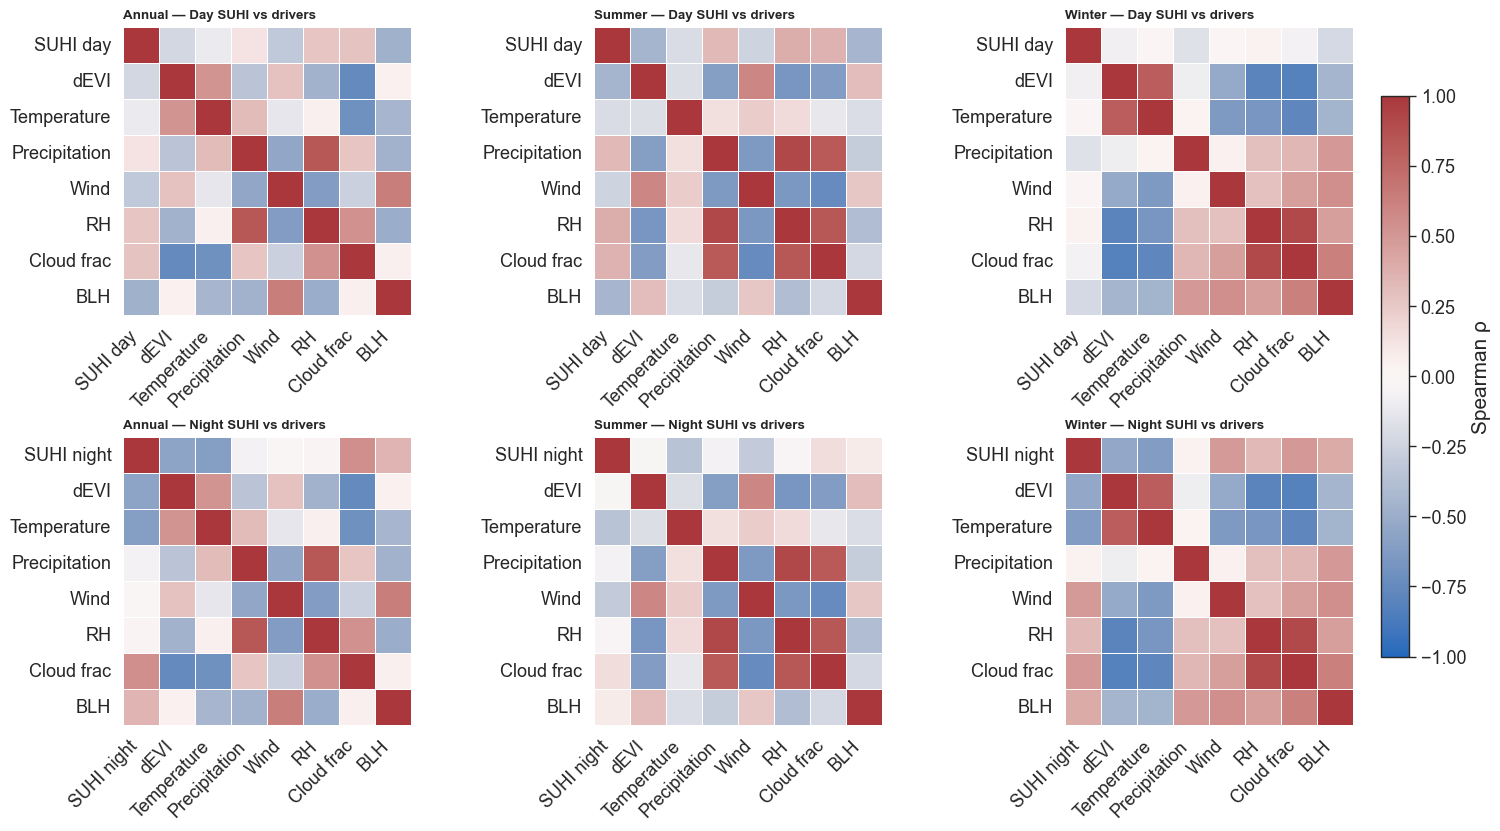

Saved correlation tables to: paper_outputs_final\tables


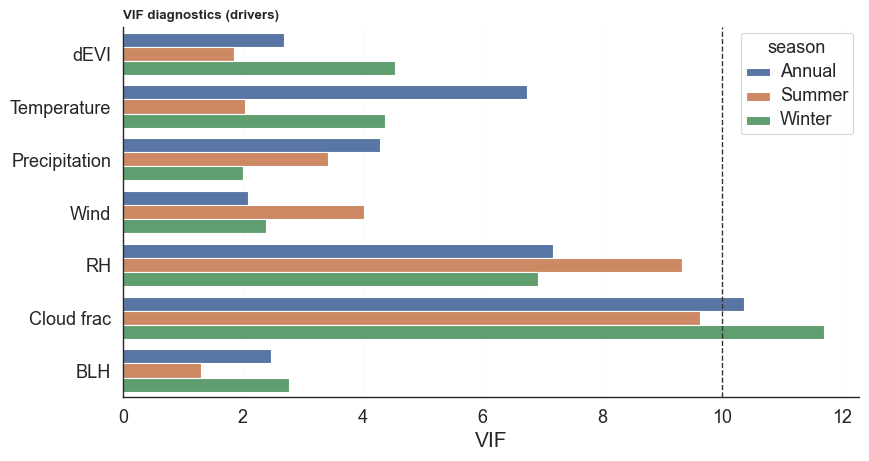

Saved: paper_outputs_final\tables\TableS3_FE_regressions_cluster_city.csv


In [22]:

# =========================
# SUPP Fig S1: Spearman correlations (SUHI vs drivers) + Tables
# SUPP Fig S2: VIF diagnostics + Table
# SUPP Table S3: FE regression tables (clustered by city)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor


def spearman_corr_p(df, cols, min_pair_n=10):
    n = len(cols)
    corr = pd.DataFrame(np.nan, index=cols, columns=cols)
    pmat = pd.DataFrame(np.nan, index=cols, columns=cols)
    for i in range(n):
        for j in range(n):
            a = df[cols[i]]
            b = df[cols[j]]
            m = a.notna() & b.notna()
            if m.sum() >= min_pair_n:
                r, p = spearmanr(a[m], b[m])
                corr.iloc[i, j] = r
                pmat.iloc[i, j] = p
    return corr, pmat


def supp_fig1_corr(panel, name="SFig1_SpearmanCorr_DayNight_bySeason"):
    seasons = ["Annual", "Summer", "Winter"]

    drivers = [v for v in [
        "dEVI_mean", "t2m_C_mean", "precip_mm_mean", "wind10_ms_mean",
        "rh_pct_mean", "cloud_frac_mean", "blh_m_mean"
    ] if v in panel.columns]

    vars_day   = [YDAY]   + drivers
    vars_night = [YNIGHT] + drivers

    fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.2), constrained_layout=True)

    for j, season in enumerate(seasons):
        ds = panel[panel["season"] == season].copy()

        corr_d, _ = spearman_corr_p(ds, vars_day)
        corr_n, _ = spearman_corr_p(ds, vars_night)

        corr_d = corr_d.rename(index=pretty_driver, columns=pretty_driver)
        corr_n = corr_n.rename(index=pretty_driver, columns=pretty_driver)

        corr_d = corr_d.rename(index={pretty_driver(YDAY): "SUHI day"},
                               columns={pretty_driver(YDAY): "SUHI day"})
        corr_n = corr_n.rename(index={pretty_driver(YNIGHT): "SUHI night"},
                               columns={pretty_driver(YNIGHT): "SUHI night"})

        sns.heatmap(
            corr_d, ax=axes[0, j], vmin=-1, vmax=1, center=0, cmap="vlag",
            square=True, linewidths=0.5, linecolor="white", cbar=False
        )
        axes[0, j].set_title(f"{season} — Day SUHI vs drivers", loc="left", fontweight="bold")
        axes[0, j].tick_params(axis="x", rotation=45)
        for lab in axes[0, j].get_xticklabels():
            lab.set_horizontalalignment("right")

        sns.heatmap(
            corr_n, ax=axes[1, j], vmin=-1, vmax=1, center=0, cmap="vlag",
            square=True, linewidths=0.5, linecolor="white", cbar=False
        )
        axes[1, j].set_title(f"{season} — Night SUHI vs drivers", loc="left", fontweight="bold")
        axes[1, j].tick_params(axis="x", rotation=45)
        for lab in axes[1, j].get_xticklabels():
            lab.set_horizontalalignment("right")

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap="vlag"),
        ax=axes, fraction=0.02, pad=0.02
    )
    cbar.set_label("Spearman ρ")

    save_fig_multi(fig, FIG_SUPP / name, close=False)
    plt.show()


# ---- Run SFig1 ----
supp_fig1_corr(panel)

# ---- Table S1: correlation matrices ----
drivers = [v for v in [
    "dEVI_mean", "t2m_C_mean", "precip_mm_mean", "wind10_ms_mean",
    "rh_pct_mean", "cloud_frac_mean", "blh_m_mean"
] if v in panel.columns]

for season in ["Annual", "Summer", "Winter"]:
    ds = panel[panel["season"] == season].copy()
    corr_d, _ = spearman_corr_p(ds, [YDAY] + drivers)
    corr_n, _ = spearman_corr_p(ds, [YNIGHT] + drivers)
    corr_d = corr_d.rename(index=pretty_driver, columns=pretty_driver)
    corr_n = corr_n.rename(index=pretty_driver, columns=pretty_driver)
    corr_d.to_csv(TAB_SUPP / f"TableS1_corr_{season}_day.csv")
    corr_n.to_csv(TAB_SUPP / f"TableS1_corr_{season}_night.csv")

print("Saved correlation tables to:", TAB_SUPP)


def compute_vif(df, xvars):
    d = df.dropna(subset=xvars).copy()
    X = d[xvars].astype(float)
    X = sm.add_constant(X)
    out = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        out.append([col, variance_inflation_factor(X.values, i)])
    return pd.DataFrame(out, columns=["var", "VIF"])


vif_rows = []
for season in ["Annual", "Summer", "Winter"]:
    ds = panel[panel["season"] == season].copy()
    v = compute_vif(ds, drivers)
    v["season"] = season
    vif_rows.append(v)

vif_df = pd.concat(vif_rows, ignore_index=True)
vif_df["var_pretty"] = vif_df["var"].map(pretty_driver)
vif_df.to_csv(TAB_SUPP / "TableS2_VIF_bySeason.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.barplot(data=vif_df, x="VIF", y="var_pretty", hue="season", ax=ax)
ax.axvline(10, color="0.2", lw=1, ls="--")
ax.set_title("VIF diagnostics (drivers)", loc="left", fontweight="bold")
ax.set_ylabel("")
ax.grid(axis="x", color="0.93", lw=0.8)
sns.despine(ax=ax)
save_fig_multi(fig, FIG_SUPP / "SFig2_VIF_Drivers_bySeason", close=False)
plt.show()


def fe_model(df, ycol, xvars):
    d = df.dropna(subset=[ycol] + xvars + ["city", "year"]).copy()
    f = f"{ycol} ~ " + " + ".join(xvars) + " + C(city) + C(year)"
    m = smf.ols(f, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})
    return m

rows = []
for season in ["Annual", "Summer", "Winter"]:
    ds = panel[panel["season"] == season].copy()
    for tod, ycol in [("Day", YDAY), ("Night", YNIGHT)]:
        m = fe_model(ds, ycol, drivers)
        for v in drivers:
            rows.append([
                season, tod, pretty_driver(v),
                float(m.params.get(v, np.nan)),
                float(m.bse.get(v, np.nan)),
                float(m.pvalues.get(v, np.nan)),
                float(m.rsquared),
            ])

regtab = pd.DataFrame(rows, columns=["season", "time", "var", "beta", "se", "p", "R2"])
regtab.to_csv(TAB_SUPP / "TableS3_FE_regressions_cluster_city.csv", index=False)
print("Saved:", TAB_SUPP / "TableS3_FE_regressions_cluster_city.csv")


# Robustness & Mechanism

- **Tail behaviour & persistence** (extreme warm years / persistent hot nights)
- **Driscoll–Kraay sensitivity** (dependence-robust inference)
- **Nonlinearity & interactions** (ΔEVI² and ΔEVI×RH/Wind/BLH)
- **Leave‑one‑city‑out (LOCO)** stability
- **City heterogeneity** in ΔEVI sensitivity

Saved: paper_outputs_final\figures_supp\SuppFig_PersistenceSensitivity_Grid.png


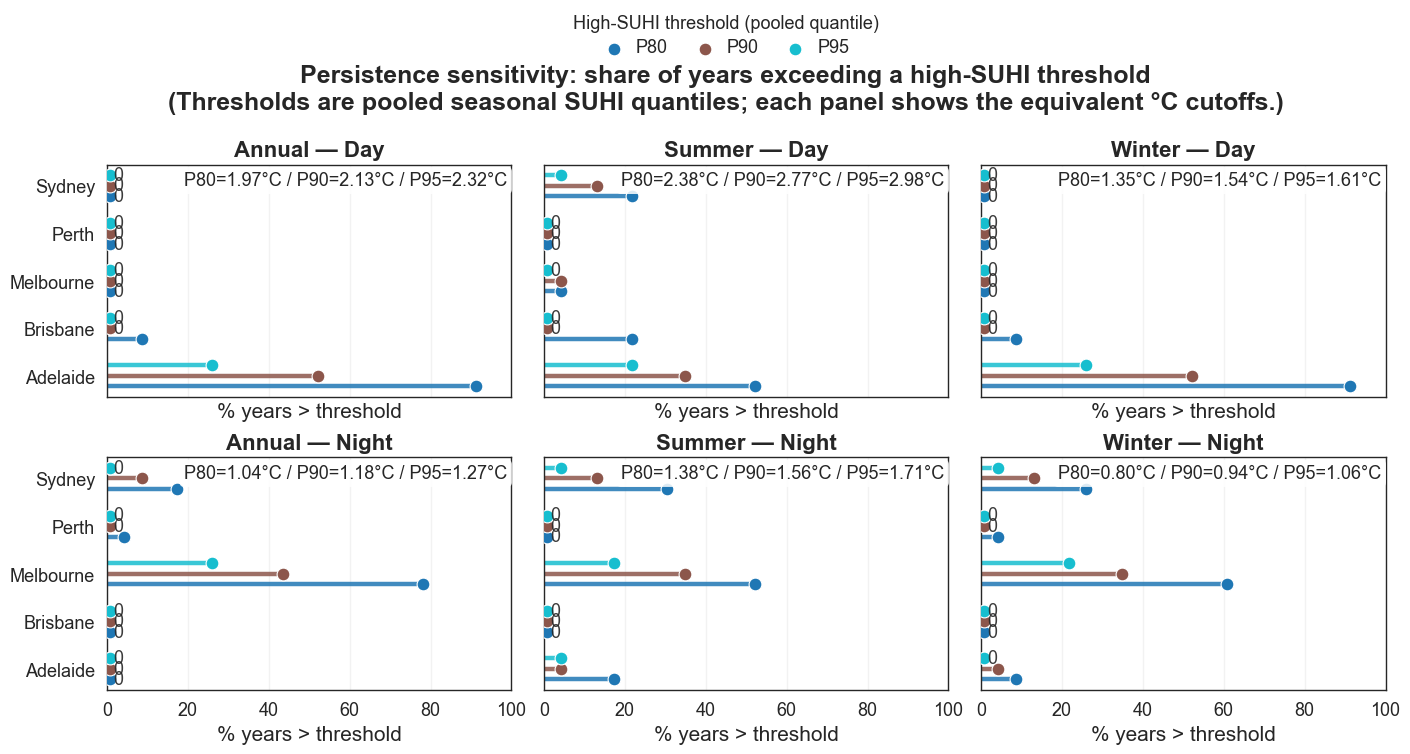

In [23]:
# =========================
# SUPP Fig — Persistence sensitivity (ONE figure: seasons × day/night)
# =========================
# What it shows:
#   For each city, the % of years where SUHI exceeds a "high-SUHI" threshold.
#   Thresholds are defined per (season, tod) using pooled distribution quantiles (e.g., 0.80, 0.90, 0.95).
# Expects: `panel` with columns: city, year, season, and YDAY/YNIGHT.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PERSIST_QS = [0.80, 0.90, 0.95]  # change if you want fewer/more
PERSIST_LABELS = {0.80:"P80", 0.90:"P90", 0.95:"P95"}

def compute_persistence_sensitivity(panel_df, seasons=("Annual","Summer","Winter"),
                                    tods=(("Day", YDAY), ("Night", YNIGHT)),
                                    qs=PERSIST_QS):
    rows=[]
    for season in seasons:
        d0 = panel_df[panel_df["season"]==season].copy()
        for tod, ycol in tods:
            d = d0.dropna(subset=["city","year",ycol]).copy()
            if d.empty:
                continue

            vals = pd.to_numeric(d[ycol], errors="coerce").dropna().values
            if len(vals) < 10:
                continue

            thr_map = {q: float(np.quantile(vals, q)) for q in qs}

            for city, g in d.groupby("city"):
                y = pd.to_numeric(g[ycol], errors="coerce")
                n = int(y.notna().sum())
                if n == 0:
                    continue
                for q, thr in thr_map.items():
                    pct = float(np.mean(y > thr) * 100.0)
                    rows.append({
                        "city": city, "season": season, "tod": tod,
                        "thr_q": q, "thr_label": PERSIST_LABELS.get(q, f"Q{int(q*100)}"),
                        "thr_value": thr, "pct_years_gt_thr": pct,
                        "n_years": n,
                    })
    out = pd.DataFrame(rows)
    # enforce uniqueness for plotting safety
    if not out.empty:
        out = (out.groupby(["city","season","tod","thr_label"], as_index=False)
                  .agg({"pct_years_gt_thr":"mean","n_years":"max","thr_q":"first","thr_value":"first"}))
    return out
def plot_persistence_sensitivity_grid(
    tail_sens,
    outpath=None,
    seasons=("Annual","Summer","Winter"),
    tods=("Day","Night"),
    show_city_labels="left",
    # readability knobs
    stem_lw=3.0,
    stem_alpha=0.85,
    marker_s=70,
    marker_edge_lw=0.8,
    zero_nudge=0.6,         
    small_tick_font=13,
    city_font=13,
    title_font=17,
    panel_title_font=15,
    add_zero_labels=True   
):
    import numpy as np
    import matplotlib.pyplot as plt

    df = tail_sens.copy()
    if df.empty:
        raise ValueError("tail_sens is empty — persistence sensitivity cannot be plotted.")

    cities = sorted(df["city"].unique())
    thr_levels = [x for x in ["P80","P90","P95"] if x in set(df["thr_label"].unique())]
    if not thr_levels:
        thr_levels = sorted(df["thr_label"].unique())

    ncity = len(cities)
    base_h = 7.4
    extra = max(0, (ncity - 10)) * 0.18
    fig_h = min(16.0, base_h + extra)

    fig, axes = plt.subplots(2, 3, figsize=(16.5, fig_h), sharex=True, sharey=True)

    thr_colors = dict(zip(thr_levels, plt.cm.tab10(np.linspace(0, 1, len(thr_levels)))))

    y = np.arange(len(cities))
    offsets = np.linspace(-0.22, 0.22, num=max(len(thr_levels), 1))

    for r, tod in enumerate(tods):
        for c, season in enumerate(seasons):
            ax = axes[r, c]

            # ---- Panel title ----
            ax.set_title(f"{season} — {tod}", fontweight="bold", fontsize=panel_title_font)

            # ---- Panel-specific threshold °C values (since quantiles differ by season/tod) ----
            thr_txt_parts = []
            for thr in thr_levels:
                sub = df[(df["season"]==season) & (df["tod"]==tod) & (df["thr_label"]==thr)]
                if not sub.empty:
                    # pooled quantile threshold should be identical across cities
                    thrC = float(sub["thr_value"].iloc[0])
                    thr_txt_parts.append(f"{thr}={thrC:.2f}°C")
            thr_txt = " / ".join(thr_txt_parts) if thr_txt_parts else ""

            if thr_txt:
                ax.text(
                    0.99, 0.97, thr_txt,
                    transform=ax.transAxes,
                    ha="right", va="top",
                    fontsize=small_tick_font,
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
                    zorder=10
                )

            # ---- Plot lollipops ----
            for k, thr in enumerate(thr_levels):
                ss = df[(df["season"]==season) & (df["tod"]==tod) & (df["thr_label"]==thr)].copy()
                ss = ss.set_index("city").reindex(cities).reset_index()  # one row per city (safe)

                xx = ss["pct_years_gt_thr"].astype(float).values
                yy = y + offsets[k]

                xplot = np.where(xx <= 0, zero_nudge, xx)

                ax.hlines(yy, 0, xplot, linewidth=stem_lw, alpha=stem_alpha, color=thr_colors[thr])
                ax.scatter(
                    xplot, yy,
                    s=marker_s,
                    color=thr_colors[thr],
                    edgecolors="white",
                    linewidth=marker_edge_lw,
                    label=thr,
                    zorder=3
                )

                if add_zero_labels:
                    # annotate true zeros (optional)
                    zero_mask = (xx <= 0)
                    if np.any(zero_mask):
                        for xi, yi in zip(xplot[zero_mask], yy[zero_mask]):
                            ax.text(xi + 0.8, yi, "0", va="center", ha="left",
                                    fontsize=small_tick_font, alpha=0.9)

            ax.set_xlim(0, 100)
            ax.grid(True, axis="x", alpha=0.25, linewidth=1.0)
            ax.set_xlabel("% years > threshold", fontsize=small_tick_font)

            ax.set_yticks(y)

            if show_city_labels == "all":
                ax.set_yticklabels(cities, fontsize=city_font)
                ax.tick_params(labelleft=True)
            elif show_city_labels == "left":
                if c == 0:
                    ax.set_yticklabels(cities, fontsize=city_font)
                    ax.tick_params(labelleft=True)
                else:
                    ax.tick_params(labelleft=False)
            else:
                ax.tick_params(labelleft=False)

            ax.tick_params(axis="x", labelsize=small_tick_font)

    handles, labels = axes[0,0].get_legend_handles_labels()
    if handles:
        # unique in order
        seen=set()
        uniq=[]
        for h,l in zip(handles, labels):
            if l not in seen:
                uniq.append((h,l))
                seen.add(l)
        handles, labels = zip(*uniq)

        leg = fig.legend(
            handles, labels,
            title="High-SUHI threshold (pooled quantile)",
            loc="upper center",
            ncol=min(len(labels), 6),
            frameon=False,
            bbox_to_anchor=(0.5, 1.03),   # << push legend ABOVE canvas
            borderaxespad=0.0
        )
        plt.setp(leg.get_title(), fontsize=16)

    fig.suptitle(
        "Persistence sensitivity: share of years exceeding a high-SUHI threshold\n"
        "(Thresholds are pooled seasonal SUHI quantiles; each panel shows the equivalent °C cutoffs.)",
        y=0.955, fontsize=15, fontweight="bold"
    )

    fig.subplots_adjust(top=0.82, hspace=0.26, wspace=0.08)

    if outpath:
        apply_large_figure_text(fig)
        fig.savefig(outpath, dpi=350, bbox_inches="tight")
        print("Saved:", outpath)

    return fig
tail_sens = compute_persistence_sensitivity(panel)
fig = plot_persistence_sensitivity_grid(
    tail_sens,
    outpath=str(FIG_SUPP / "SuppFig_PersistenceSensitivity_Grid.png"),
    show_city_labels="left",
    stem_lw=3.2,
    marker_s=85,
    zero_nudge=0.8
)
plt.show()

Saved: paper_outputs_final\figures_main\MainFig_SUHI_P90_Intensity_and_P90_Persistence.png


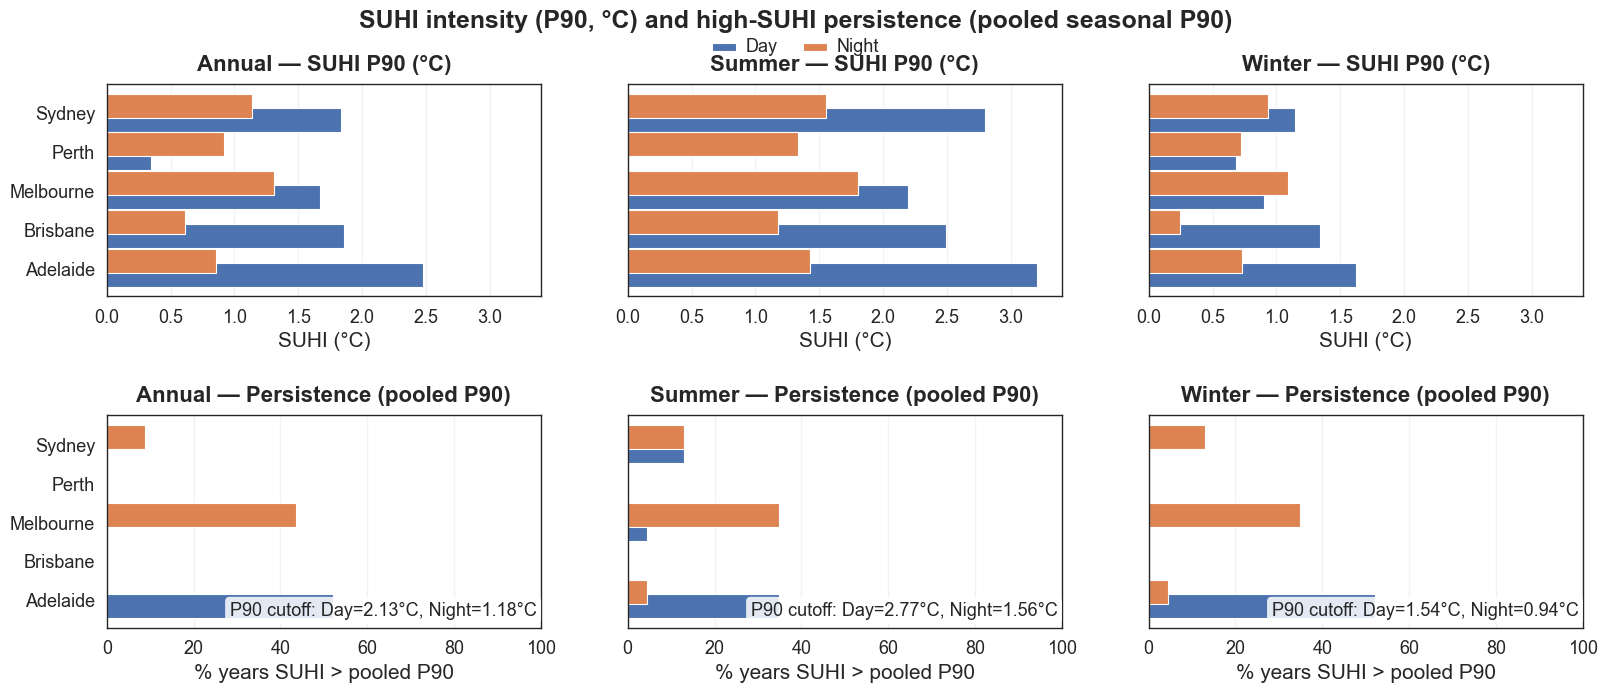

In [24]:

# =========================
# MAIN Fig: SUHI intensity (P90) + high-SUHI persistence (pooled seasonal P90)
# =========================
# Layout: 2 rows × 3 cols (Annual / Summer / Winter)
#   Row 1: SUHI intensity in °C = P90 across years of seasonal-mean SUHI
#   Row 2: Persistence = % years with seasonal mean SUHI > pooled seasonal P90 threshold

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEASONS_MAIN = ("Annual", "Summer", "Winter")
TODS_MAIN = (("Day", YDAY), ("Night", YNIGHT))
SUHI_INTENSITY_METRIC = "p90"
SUHI_INTENSITY_Q = 0.90
PERSIST_Q = 0.90
PERSIST_LABEL = "P90"


def _agg_city_year_season(panel_df, seasons=SEASONS_MAIN, tods=TODS_MAIN):
    keep = ["city", "year", "season"] + [ycol for _, ycol in tods]
    d = panel_df[keep].copy()
    d["city"] = d["city"].astype(str)
    d["season"] = d["season"].astype(str)
    d["year"] = pd.to_numeric(d["year"], errors="coerce").astype("Int64")
    for _, ycol in tods:
        d[ycol] = pd.to_numeric(d[ycol], errors="coerce")
    d = d.dropna(subset=["city", "year", "season"]).copy()
    agg_map = {ycol: "mean" for _, ycol in tods}
    d = (d.groupby(["city", "year", "season"], observed=True)
           .agg(agg_map)
           .reset_index())
    d = d[d["season"].isin(seasons)].copy()
    d["year"] = d["year"].astype(int)
    return d


def compute_suhi_intensity(panel_df, seasons=SEASONS_MAIN, tods=TODS_MAIN,
                           metric=SUHI_INTENSITY_METRIC, q=SUHI_INTENSITY_Q):
    d = _agg_city_year_season(panel_df, seasons=seasons, tods=tods)
    rows = []
    for season in seasons:
        ds = d[d["season"] == season].copy()
        for tod, ycol in tods:
            for city, g in ds.groupby("city"):
                vals = g[ycol].dropna().values
                if len(vals) == 0:
                    val = np.nan
                elif metric == "mean":
                    val = float(np.mean(vals))
                elif metric in ("p90", "p95", "p80"):
                    val = float(np.quantile(vals, q))
                else:
                    raise ValueError("metric must be 'mean' or 'pXX' with matching q")
                rows.append({"city": city, "season": season, "tod": tod, "suhi_C": val})
    return pd.DataFrame(rows)


def compute_persistence_pooled_quantile(panel_df, seasons=SEASONS_MAIN, tods=TODS_MAIN, q=PERSIST_Q):
    d = _agg_city_year_season(panel_df, seasons=seasons, tods=tods)
    rows = []
    for season in seasons:
        ds = d[d["season"] == season].copy()
        for tod, ycol in tods:
            pooled = ds[ycol].dropna().values
            if len(pooled) < 10:
                continue
            thr = float(np.quantile(pooled, q))
            for city, g in ds.groupby("city"):
                y = g[ycol]
                n = int(y.notna().sum())
                if n == 0:
                    continue
                pct = float(np.mean(y > thr) * 100.0)
                rows.append({
                    "city": city,
                    "season": season,
                    "tod": tod,
                    "thr_value_C": thr,
                    "pct_years_gt_thr": pct,
                    "n_years": n,
                })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = (out.groupby(["city", "season", "tod"], as_index=False)
                 .agg({"pct_years_gt_thr": "mean", "n_years": "max", "thr_value_C": "first"}))
    return out


def plot_main_suhi_and_persistence(suhi_int_df, persist_df, outpath=None, seasons=SEASONS_MAIN,
                                   city_order=None, suhi_xlim=None, persist_xlim=(0, 100),
                                   bar_h=0.62, title_font=18, panel_title_font=17,
                                   tick_font=13, city_font=13):
    if city_order is None:
        cities = sorted(set(suhi_int_df["city"]).union(set(persist_df["city"])))
    else:
        cities = list(city_order)

    def pivot_dn(df, value_col, seasons):
        dd = df.copy()
        dd = dd[dd["season"].isin(seasons)].copy()
        wide = dd.pivot_table(index=["city", "season"], columns="tod", values=value_col, aggfunc="mean")
        for col in ["Day", "Night"]:
            if col not in wide.columns:
                wide[col] = np.nan
        return wide.reset_index()

    suhi_w = pivot_dn(suhi_int_df, "suhi_C", seasons)
    pers_w = pivot_dn(persist_df, "pct_years_gt_thr", seasons)

    thr_map = {}
    if (not persist_df.empty) and ("thr_value_C" in persist_df.columns):
        for s in seasons:
            for tod in ["Day", "Night"]:
                sub = persist_df[(persist_df["season"] == s) & (persist_df["tod"] == tod)]
                v = sub["thr_value_C"].dropna().values
                thr_map[(s, tod)] = float(v[0]) if len(v) else np.nan

    if suhi_xlim is None:
        vmax = np.nanmax(suhi_w[["Day", "Night"]].values) if len(suhi_w) else 1.0
        suhi_xlim = (0, max(1.0, float(np.ceil((vmax + 0.15) * 10) / 10)))

    ncity = len(cities)
    fig_h = min(12.5, 6.8 + 0.35 * max(0, ncity - 5))
    fig, axes = plt.subplots(2, 3, figsize=(16.4, fig_h), sharey=False)

    y = np.arange(ncity)
    off = 0.18

    for col, season in enumerate(seasons):
        ax = axes[0, col]
        sub = suhi_w[suhi_w["season"] == season].set_index("city").reindex(cities).reset_index()
        x_day = sub["Day"].astype(float).values
        x_nit = sub["Night"].astype(float).values
        ax.barh(y - off, x_day, height=bar_h, label="Day")
        ax.barh(y + off, x_nit, height=bar_h, label="Night")
        ax.set_title(f"{season} — SUHI {SUHI_INTENSITY_METRIC.upper()} (°C)", fontweight="bold", fontsize=panel_title_font, pad=10)
        ax.set_xlim(*suhi_xlim)
        ax.grid(True, axis="x", alpha=0.25, linewidth=1.0)
        ax.set_xlabel("SUHI (°C)", fontsize=tick_font)
        ax.tick_params(axis="x", labelsize=tick_font)
        ax.set_yticks(y)
        if col == 0:
            ax.set_yticklabels(cities, fontsize=city_font)
        else:
            ax.set_yticklabels([])

        ax2 = axes[1, col]
        subp = pers_w[pers_w["season"] == season].set_index("city").reindex(cities).reset_index()
        p_day = subp["Day"].astype(float).values
        p_nit = subp["Night"].astype(float).values
        ax2.barh(y - off, p_day, height=bar_h)
        ax2.barh(y + off, p_nit, height=bar_h)
        ax2.set_title(f"{season} — Persistence (pooled {PERSIST_LABEL})", fontweight="bold", fontsize=panel_title_font, pad=10)
        ax2.set_xlim(*persist_xlim)
        ax2.grid(True, axis="x", alpha=0.25, linewidth=1.0)
        ax2.set_xlabel(f"% years SUHI > pooled {PERSIST_LABEL}", fontsize=tick_font)
        ax2.tick_params(axis="x", labelsize=tick_font)
        ax2.set_yticks(y)
        if col == 0:
            ax2.set_yticklabels(cities, fontsize=city_font)
        else:
            ax2.set_yticklabels([])

        thr_d = thr_map.get((season, "Day"), np.nan)
        thr_n = thr_map.get((season, "Night"), np.nan)
        if np.isfinite(thr_d) and np.isfinite(thr_n):
            ax2.text(0.99, 0.04, f"{PERSIST_LABEL} cutoff: Day={thr_d:.2f}°C, Night={thr_n:.2f}°C",
                     transform=ax2.transAxes, ha="right", va="bottom", fontsize=tick_font,
                     bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85))

    fig.suptitle(
        f"SUHI intensity ({SUHI_INTENSITY_METRIC.upper()}, °C) and high-SUHI persistence (pooled seasonal {PERSIST_LABEL})",
        y=0.99, fontsize=title_font, fontweight="bold"
    )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2,
                   frameon=False, bbox_to_anchor=(0.5, 0.965))

    fig.subplots_adjust(top=0.88, bottom=0.08, left=0.08, right=0.98, hspace=0.56, wspace=0.20)

    if outpath:
        apply_large_figure_text(fig)
        fig.savefig(outpath, dpi=350, bbox_inches="tight")
        print("Saved:", outpath)
    return fig


suhi_int = compute_suhi_intensity(panel, seasons=SEASONS_MAIN, tods=TODS_MAIN,
                                  metric=SUHI_INTENSITY_METRIC, q=SUHI_INTENSITY_Q)
p90_persist = compute_persistence_pooled_quantile(panel, seasons=SEASONS_MAIN, tods=TODS_MAIN, q=PERSIST_Q)
city_order = sorted(panel["city"].astype(str).unique())
fig = plot_main_suhi_and_persistence(
    suhi_int_df=suhi_int,
    persist_df=p90_persist,
    outpath=str(FIG_MAIN / "MainFig_SUHI_P90_Intensity_and_P90_Persistence.png"),
    seasons=SEASONS_MAIN,
    city_order=city_order,
    suhi_xlim=None,
    persist_xlim=(0, 100),
)
plt.show()


In [25]:
import numpy as np
import pandas as pd

REQUIRED_COLS = {"city", "season", YDAY, YNIGHT}
missing = REQUIRED_COLS - set(panel.columns)
if missing:
    raise ValueError(f"panel is missing required columns: {missing}")

def build_tail_df(panel_df, ycols, q=0.95):
    """
    Tail intensity summary:
      1) Compute seasonal mean SUHI per city (mean across observations within city×season)
      2) For each season, compute q-quantile across cities of those city seasonal means
    Returns tidy df with: metric, season, city, tail_q
    """
    out = []

    df = panel_df.copy()
    df["city"] = df["city"].astype(str)
    df["season"] = df["season"].astype(str)

    for metric in ycols:
        cs_mean = (
            df[["city", "season", metric]]
            .dropna(subset=[metric])
            .groupby(["city", "season"], as_index=False, observed=True)[metric]
            .mean()
            .rename(columns={metric: "seasonal_mean"})
        )

        # for each season, quantile across cities of the seasonal mean
        for s, g in cs_mean.groupby("season", observed=True):
            tail_val = float(np.nanquantile(g["seasonal_mean"].values, q))

            tmp = g[["city"]].copy()
            tmp["season"] = s
            tmp["metric"] = metric
            tmp["tail_q"] = tail_val  # << fixed: no undefined variable

            out.append(tmp)

    return pd.concat(out, ignore_index=True)

tail = build_tail_df(panel, [YDAY, YNIGHT], q=0.95)
tail.head()

,city,season,metric,tail_q
0,Adelaide,Annual,suhi_day_C_mean,2.06199
1,Brisbane,Annual,suhi_day_C_mean,2.06199
2,Melbourne,Annual,suhi_day_C_mean,2.06199
3,Perth,Annual,suhi_day_C_mean,2.06199
4,Sydney,Annual,suhi_day_C_mean,2.06199


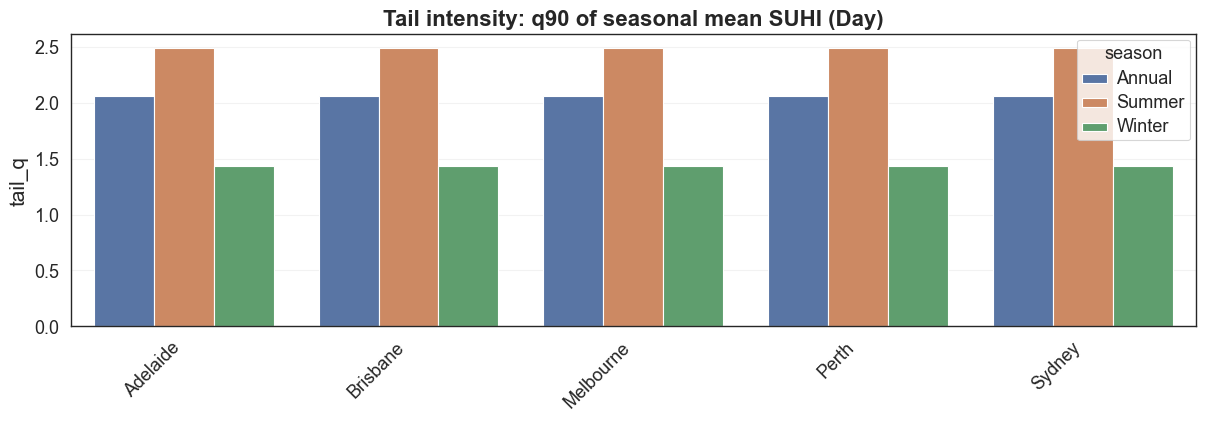

Saved: paper_outputs_final\figures_supp\SCS_tail_q90_day.png


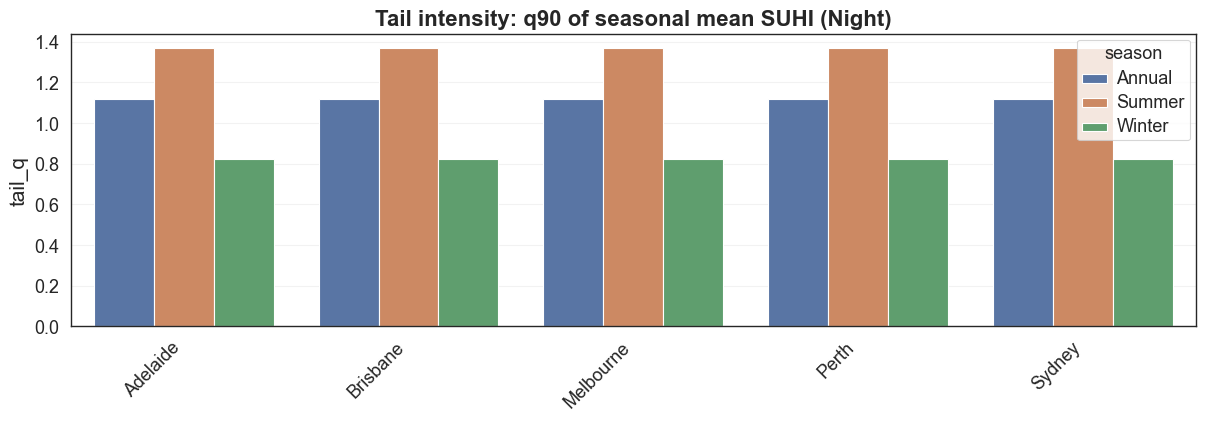

Saved: paper_outputs_final\figures_supp\SCS_tail_q90_night.png


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def bar_tail(df_tail, metric, value, title, outpng):
    d = df_tail[df_tail["metric"] == metric].copy()
    if d.empty:
        raise ValueError(f"No rows found for metric={metric}. Check YDAY/YNIGHT names.")

    city_order = (
        d.groupby("city", observed=True)[value]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.barplot(
        data=d, x="city", y=value, hue="season",
        order=city_order, ax=ax, errorbar=None
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(value)
    ax.grid(True, axis="y", alpha=0.25)

    ax.tick_params(axis="x", rotation=45)
    for lab in ax.get_xticklabels():
        lab.set_horizontalalignment("right")

    fig.tight_layout()

    outpng = Path(outpng)
    outpng.parent.mkdir(parents=True, exist_ok=True)
    apply_large_figure_text(fig)
    fig.savefig(outpng, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outpng)

bar_tail(tail, YDAY, "tail_q", "Tail intensity: q90 of seasonal mean SUHI (Day)", OUTDIR/"figures_supp"/"SCS_tail_q90_day.png")
bar_tail(tail, YNIGHT, "tail_q", "Tail intensity: q90 of seasonal mean SUHI (Night)", OUTDIR/"figures_supp"/"SCS_tail_q90_night.png")

In [27]:

# =========================
# Robustness helpers 
# =========================

if "panel" not in globals():
    raise NameError("`panel` is not defined yet. Run the data preparation / panel construction cells first.")

# Identify ΔEVI column (required)
_EVI_CANDS = ["dEVI_mean","dEVI","delta_evi","EVI_diff","EVI_urb_minus_rur","dEVI_z"]
EVI_COL = next((c for c in _EVI_CANDS if c in panel.columns), None)
if EVI_COL is None:
    raise NameError("Could not find a ΔEVI column in `panel`. Expected one of: " + ", ".join(_EVI_CANDS))

_DEFAULT_X = [
    EVI_COL,
    "t2m_C_mean",
    "rh_pct_mean",
    "wind10_ms_mean",
    "precip_mm_mean",
    "cloud_frac_mean",
    "blh_m_mean",
]

if "VARS" in globals() and isinstance(VARS, list) and len(VARS) > 0:
    # Ensure ΔEVI is first
    XFULL = [EVI_COL] + [v for v in VARS if v != EVI_COL]
else:
    XFULL = [v for v in _DEFAULT_X if v in panel.columns]

# Outcomes
if "YDAY" not in globals():
    YDAY = "suhi_day_C_mean"
if "YNIGHT" not in globals():
    YNIGHT = "suhi_night_C_mean"

print("EVI_COL:", EVI_COL)
print("XFULL:", XFULL)
print("YDAY/YNIGHT:", YDAY, YNIGHT)


EVI_COL: dEVI_mean
XFULL: ['dEVI_mean', 't2m_C_mean', 'precip_mm_mean', 'wind10_ms_mean', 'rh_pct_mean', 'cloud_frac_mean', 'blh_m_mean']
YDAY/YNIGHT: suhi_day_C_mean suhi_night_C_mean


In [28]:

# Cell — Driscoll–Kraay sensitivity using PanelOLS when available
# Fallback: clustered two-way FE table only if linearmodels is unavailable.

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

try:
    from linearmodels.panel import PanelOLS
    HAVE_PANELOLS = True
except Exception:
    HAVE_PANELOLS = False
    print("linearmodels is not installed; Driscoll–Kraay estimates will be skipped and clustered FE estimates will be saved instead.")

rows = []

if HAVE_PANELOLS:
    import statsmodels.api as sm

    def panelols_fit(df, y, X):
        d = df.dropna(subset=[y] + X + ["city", "year"]).copy()
        d = d.set_index(["city", "year"]).sort_index()
        yv = d[y]
        Xv = sm.add_constant(d[X], has_constant="add")
        mod = PanelOLS(yv, Xv, entity_effects=True, time_effects=True)
        res_cluster = mod.fit(cov_type="clustered", cluster_entity=True)
        res_dk = mod.fit(cov_type="driscoll-kraay")
        return res_cluster, res_dk

    for season in ["Annual", "Summer", "Winter"]:
        ds = panel[panel["season"] == season].copy()
        for y in [YDAY, YNIGHT]:
            if y not in panel.columns:
                continue
            res_cl, res_dk = panelols_fit(ds, y, XFULL)
            for label, res in [("cluster_city", res_cl), ("driscoll_kraay", res_dk)]:
                for term in ["const"] + XFULL:
                    rows.append({
                        "season": season,
                        "y": y,
                        "cov": label,
                        "term": term,
                        "coef": float(res.params.get(term, np.nan)),
                        "se": float(res.std_errors.get(term, np.nan)),
                        "p": float(res.pvalues.get(term, np.nan))
                    })
else:
    def fe_cluster_fit(df, ycol, xvars):
        d = df.dropna(subset=[ycol] + xvars + ["city", "year"]).copy()
        f = f"{ycol} ~ " + " + ".join(xvars) + " + C(city) + C(year)"
        m = smf.ols(f, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})
        return m

    for season in ["Annual", "Summer", "Winter"]:
        ds = panel[panel["season"] == season].copy()
        for y in [YDAY, YNIGHT]:
            if y not in panel.columns:
                continue
            res_cl = fe_cluster_fit(ds, y, XFULL)
            for term in XFULL:
                rows.append({
                    "season": season,
                    "y": y,
                    "cov": "cluster_city",
                    "term": term,
                    "coef": float(res_cl.params.get(term, np.nan)),
                    "se": float(res_cl.bse.get(term, np.nan)),
                    "p": float(res_cl.pvalues.get(term, np.nan))
                })
            for term in XFULL:
                rows.append({
                    "season": season,
                    "y": y,
                    "cov": "driscoll_kraay_unavailable",
                    "term": term,
                    "coef": np.nan,
                    "se": np.nan,
                    "p": np.nan
                })

dk_tbl = pd.DataFrame(rows)
dk_path = OUTDIR / "tables" / "PanelOLS_cluster_vs_DK.csv"
dk_tbl.to_csv(dk_path, index=False)
print("Saved:", dk_path)
display(dk_tbl.head())


linearmodels is not installed; Driscoll–Kraay estimates will be skipped and clustered FE estimates will be saved instead.
Saved: paper_outputs_final\tables\PanelOLS_cluster_vs_DK.csv


,season,y,cov,term,coef,se,p
0,Annual,suhi_day_C_mean,cluster_city,dEVI_mean,-20.597400,4.624318,0.000008
1,Annual,suhi_day_C_mean,cluster_city,t2m_C_mean,-0.077743,0.113683,0.494066
2,Annual,suhi_day_C_mean,cluster_city,precip_mm_mean,-0.000896,0.004048,0.824776
3,Annual,suhi_day_C_mean,cluster_city,wind10_ms_mean,-0.060181,0.082891,0.467827
4,Annual,suhi_day_C_mean,cluster_city,rh_pct_mean,0.041143,0.020754,0.047436


In [29]:

# =========================
# Actionable effect sizes (no standardization)
# =========================
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


def fe_effect_sizes(panel, season, ycol, xvars, evi_col=None):
    if evi_col is None:
        evi_col = globals().get('EVI_COL', 'dEVI_mean')
    if evi_col not in panel.columns:
        raise NameError(f"ΔEVI column '{evi_col}' not found in panel.")

    d = panel[(panel["season"] == season)].dropna(subset=[ycol] + xvars + [evi_col, "city", "year"]).copy()
    f = f"{ycol} ~ " + " + ".join(xvars) + " + C(city) + C(year)"
    res = smf.ols(f, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})

    beta = float(res.params.get(evi_col, np.nan))
    se   = float(res.bse.get(evi_col, np.nan))

    eff_01 = beta * 0.1
    eff_01_ci = 1.96 * se * 0.1

    q25, q75 = np.nanpercentile(d[evi_col].values, [25, 75])
    iqr = float(q75 - q25)
    eff_iqr = beta * iqr
    eff_iqr_ci = 1.96 * se * iqr

    return {
        "season": season,
        "y": ycol,
        "beta_dEVI": beta,
        "se": se,
        "dEVI_IQR": iqr,
        "SUHI_per_0.1_dEVI": eff_01,
        "SUHI_per_0.1_dEVI_ci95": eff_01_ci,
        "SUHI_per_IQR_dEVI": eff_iqr,
        "SUHI_per_IQR_dEVI_ci95": eff_iqr_ci,
        "n": int(len(d)),
        "n_city": int(d["city"].nunique()),
        "n_year": int(d["year"].nunique()),
    }


if "dEVI_mean" in panel.columns and "dEVI_mean" in XFULL:
    eff_rows = []
    for season in ["Annual", "Summer", "Winter"]:
        for ycol in [YDAY, YNIGHT]:
            if ycol not in panel.columns:
                continue
            eff_rows.append(fe_effect_sizes(panel, season, ycol, XFULL, evi_col="dEVI_mean"))
    eff_tbl = pd.DataFrame(eff_rows)
    eff_path = OUTDIR / "tables" / "SCS_effect_sizes_dEVI_units.csv"
    eff_tbl.to_csv(eff_path, index=False)
    display(eff_tbl)
    print("Saved:", eff_path)
else:
    print("ΔEVI column not found in panel/XFULL; skip effect-size table.")


,season,y,beta_dEVI,se,dEVI_IQR,SUHI_per_0.1_dEVI,SUHI_per_0.1_dEVI_ci95,SUHI_per_IQR_dEVI,SUHI_per_IQR_dEVI_ci95,n,n_city,n_year
0,Annual,suhi_day_C_mean,-20.597400,4.624318,0.018083,-2.059740,0.906366,-0.372465,0.163899,115,5,23
1,Annual,suhi_night_C_mean,0.698270,1.435260,0.018083,0.069827,0.281311,0.012627,0.050870,115,5,23
2,Summer,suhi_day_C_mean,-29.050460,3.854629,0.025538,-2.905046,0.755507,-0.741901,0.192944,115,5,23
3,Summer,suhi_night_C_mean,-2.078903,2.086850,0.025538,-0.207890,0.409023,-0.053092,0.104458,115,5,23
4,Winter,suhi_day_C_mean,-6.880513,1.886946,0.026764,-0.688051,0.369841,-0.184149,0.098984,115,5,23
5,Winter,suhi_night_C_mean,-0.339725,1.964195,0.026764,-0.033973,0.384982,-0.009092,0.103036,115,5,23


Saved: paper_outputs_final\tables\SCS_effect_sizes_dEVI_units.csv


Saved: paper_outputs_final\figures_main\MainFig_StandardizedEffects_Grid.png


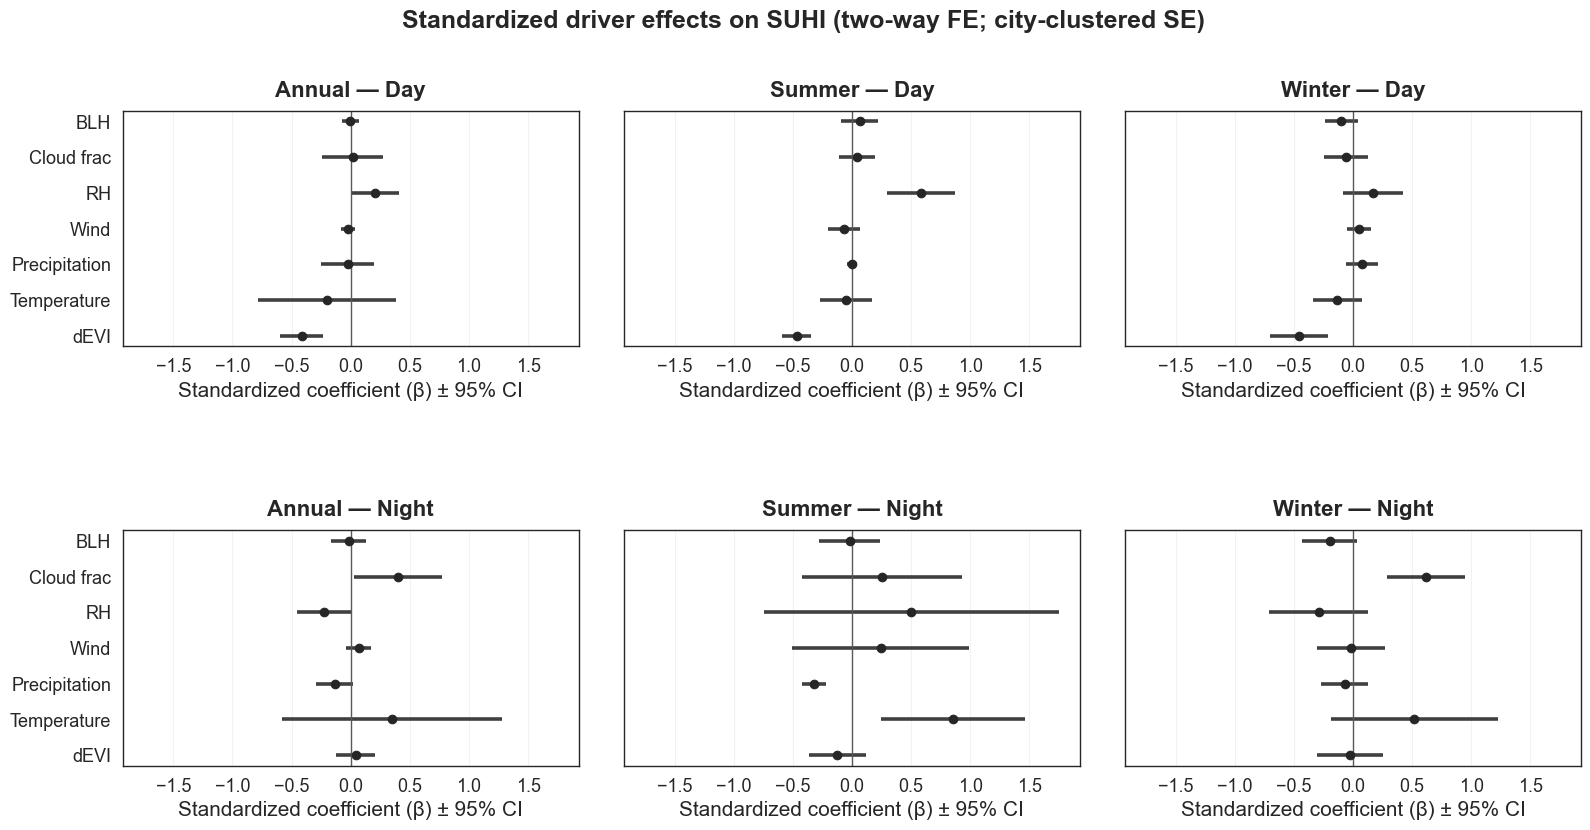

In [30]:

# =========================
# MAIN — Standardized driver effects (two-way FE; city-clustered SE)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

SEASONS = ["Annual", "Summer", "Winter"]
TODS = [("Day", YDAY), ("Night", YNIGHT)]

def zscore_series(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / (s.std(ddof=0) + 1e-12)

def fit_std_betas(ds, ycol, xvars):
    d = ds.dropna(subset=[ycol, "city", "year"] + xvars).copy()
    if d.empty:
        return pd.DataFrame(columns=["var","beta","lo","hi","label"])

    d[ycol] = zscore_series(d[ycol])
    for v in xvars:
        d[v] = zscore_series(d[v])

    f = f"{ycol} ~ " + " + ".join(xvars) + " + C(city) + C(year)"
    m = smf.ols(f, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})

    rows = []
    for v in xvars:
        b  = float(m.params.get(v, np.nan))
        se = float(m.bse.get(v, np.nan))
        rows.append({
            "var": v,
            "beta": b,
            "lo": b - 1.96 * se,
            "hi": b + 1.96 * se,
            "label": pretty_var(v),
        })
    return pd.DataFrame(rows)

def plot_std_effects_grid(panel_df, xvars, outpath=None,
                          title="Standardized driver effects on SUHI (two-way FE; city-clustered SE)"):
    xvars = [v for v in xvars if v in panel_df.columns]
    if len(xvars) == 0:
        raise ValueError("No driver columns found in panel_df for xvars.")

    yvars = list(xvars)
    ylabels = [pretty_var(v) for v in yvars]
    y = np.arange(len(yvars))

    fig, axes = plt.subplots(2, 3, figsize=(16.2, 8.4), sharey=True)

    cache = {}
    all_lo, all_hi = [], []
    for r, (tod, ycol) in enumerate(TODS):
        for c, season in enumerate(SEASONS):
            ds = panel_df[panel_df["season"] == season].copy()
            bet = fit_std_betas(ds, ycol, xvars=yvars)
            bet = bet.set_index("var").reindex(yvars).reset_index()
            cache[(season, tod)] = bet
            all_lo.extend(pd.to_numeric(bet["lo"], errors="coerce").tolist())
            all_hi.extend(pd.to_numeric(bet["hi"], errors="coerce").tolist())

    lim = np.nanmax(np.abs(np.r_[all_lo, all_hi])) if len(all_lo) else 0.8
    lim = max(lim, 0.5) * 1.10

    for r, (tod, ycol) in enumerate(TODS):
        for c, season in enumerate(SEASONS):
            ax = axes[r, c]
            bet = cache[(season, tod)]

            ax.hlines(y, bet["lo"], bet["hi"], lw=2.6, color="0.25")
            ax.scatter(bet["beta"], y, s=38, color="0.15", zorder=3)
            ax.axvline(0, lw=1.0, color="0.35")
            ax.set_xlim(-lim, lim)
            ax.grid(True, axis="x", alpha=0.25)
            ax.set_title(f"{season} — {tod}", fontweight="bold", pad=10)
            ax.set_xlabel("Standardized coefficient (β) ± 95% CI")

            ax.set_yticks(y)
            if c == 0:
                ax.set_yticklabels(ylabels)
            else:
                ax.tick_params(labelleft=False)

    fig.suptitle(title, y=0.98, fontweight="bold")
    fig.subplots_adjust(top=0.86, bottom=0.08, left=0.08, right=0.98, hspace=0.78, wspace=0.10)

    if outpath:
        apply_large_figure_text(fig)
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print("Saved:", outpath)

    return fig

# ---- RUN ----
fig = plot_std_effects_grid(
    panel,
    xvars=[v for v in XFULL if v in panel.columns],
    outpath=str(FIG_MAIN / "MainFig_StandardizedEffects_Grid.png")
)
plt.show()


Saved: paper_outputs_final\figures_main\MainFig_CitySpecific_EVI_Sensitivity_Grid.png


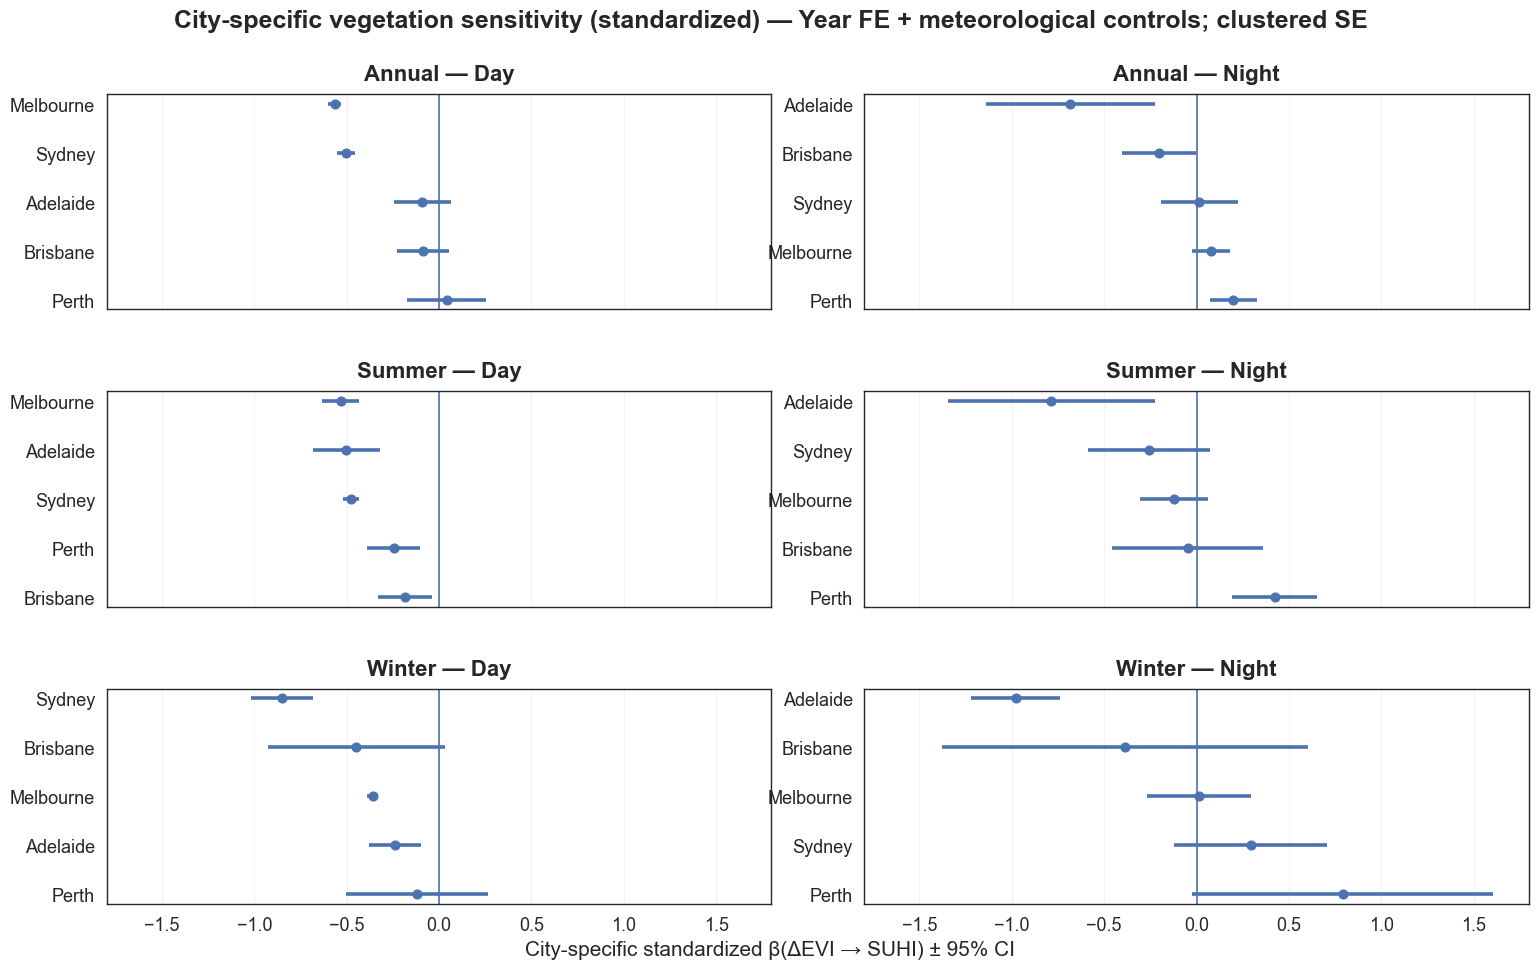

In [36]:

# =========================
# MAIN Fig — City-specific vegetation sensitivity (standardized)
# =========================
# This figure complements the pooled FE model by extracting city-specific
# ΔEVI slopes from an interaction model:
#   z(SUHI) ~ z(ΔEVI) × city + z(meteorological controls) + year FE
# Standard errors are clustered by city, consistent with the pooled models.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

SEASONS = ["Annual", "Summer", "Winter"]
TODS = [("Day", YDAY), ("Night", YNIGHT)]
EVI_INT = EVI_COL if "EVI_COL" in globals() else "dEVI_mean"


def _std_for_model(s):
    s = pd.to_numeric(s, errors="coerce").astype(float)
    sd = s.std(ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return s * 0.0
    return (s - s.mean()) / sd


def fit_city_specific_evi(panel_df, season, ycol, xvars, x_int=EVI_INT):
    """Fit city-specific ΔEVI slopes using a city interaction model."""
    xvars = [v for v in xvars if v in panel_df.columns]
    if x_int not in xvars:
        xvars = [x_int] + xvars

    d = panel_df[panel_df["season"] == season].dropna(
        subset=[ycol, "city", "year"] + xvars
    ).copy()

    d["city"] = d["city"].astype(str)
    d["year"] = pd.to_numeric(d["year"], errors="coerce").astype(int)

    # Standardize within each season × day/night model.
    # This makes slopes comparable across panels.
    d[ycol] = _std_for_model(d[ycol])
    for v in xvars:
        d[v] = _std_for_model(d[v])

    met_vars = [v for v in xvars if v != x_int]
    formula = f"{ycol} ~ {x_int} * C(city)"
    if met_vars:
        formula += " + " + " + ".join(met_vars)
    formula += " + C(year)"

    model = smf.ols(formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["city"]}
    )

    cities = sorted(d["city"].unique())
    params = model.params
    cov = model.cov_params()
    idx = params.index

    rows = []
    for city in cities:
        contrast = pd.Series(0.0, index=idx)
        if x_int in contrast.index:
            contrast[x_int] = 1.0

        # Statsmodels can write interaction names in either order.
        term1 = f"{x_int}:C(city)[T.{city}]"
        term2 = f"C(city)[T.{city}]:{x_int}"
        if term1 in contrast.index:
            contrast[term1] = 1.0
        if term2 in contrast.index:
            contrast[term2] = 1.0

        beta = float((contrast * params).sum())
        var = float(contrast.values @ cov.values @ contrast.values)
        se = np.sqrt(var) if np.isfinite(var) and var >= 0 else np.nan
        rows.append({
            "city": city,
            "season": season,
            "tod": "Day" if ycol == YDAY else "Night",
            "beta": beta,
            "lo": beta - 1.96 * se,
            "hi": beta + 1.96 * se,
            "se": se,
            "n": len(d)
        })

    return pd.DataFrame(rows)


def plot_city_specific_evi_sensitivity(panel_df, xvars, outpath=None):
    """Create a readable 3 × 2 grid of city-specific ΔEVI sensitivity."""
    xvars = [v for v in xvars if v in panel_df.columns]
    if EVI_INT not in xvars:
        xvars = [EVI_INT] + xvars

    cache = {}
    all_vals = []
    for i, season in enumerate(SEASONS):
        for j, (tod, ycol) in enumerate(TODS):
            tbl = fit_city_specific_evi(panel_df, season, ycol, xvars=xvars, x_int=EVI_INT)
            cache[(season, tod)] = tbl
            all_vals.extend(tbl[["lo", "hi"]].to_numpy().ravel().tolist())

    lim = np.nanmax(np.abs(all_vals)) if len(all_vals) else 1.0
    lim = max(0.5, lim * 1.12)

    fig, axes = plt.subplots(3, 2, figsize=(15.8, 10.0), sharex=True)

    for i, season in enumerate(SEASONS):
        for j, (tod, ycol) in enumerate(TODS):
            ax = axes[i, j]
            tbl = cache[(season, tod)].copy()
            tbl = tbl.sort_values("beta", ascending=False).reset_index(drop=True)
            y = np.arange(len(tbl))

            ax.hlines(y, tbl["lo"], tbl["hi"], lw=2.6, color="#4C72B0")
            ax.scatter(tbl["beta"], y, s=42, color="#4C72B0", zorder=3)
            ax.axvline(0, lw=1.2, color="#4C72B0")
            ax.set_xlim(-lim, lim)
            ax.grid(True, axis="x", alpha=0.25)
            ax.set_yticks(y)
            ax.set_yticklabels(tbl["city"].tolist())
            ax.set_title(f"{season} — {tod}", fontweight="bold", pad=10)

            # Keep individual x-axis labels off the upper rows to avoid clutter.
            if i < len(SEASONS) - 1:
                ax.set_xlabel("")
            else:
                ax.set_xlabel("")

    fig.suptitle(
        "City-specific vegetation sensitivity (standardized) — Year FE + meteorological controls; clustered SE",
        y=0.985,
        fontweight="bold"
    )
    fig.supxlabel("City-specific standardized β(ΔEVI → SUHI) ± 95% CI", y=0.035, fontsize=FIG_FONT["label"])
    fig.subplots_adjust(top=0.90, bottom=0.09, left=0.08, right=0.98, hspace=0.38, wspace=0.14)

    if outpath:
        apply_large_figure_text(fig)
        fig.savefig(outpath, dpi=350, bbox_inches="tight")
        fig.savefig(str(outpath).replace(".png", ".pdf"), bbox_inches="tight")
        fig.savefig(str(outpath).replace(".png", ".svg"), bbox_inches="tight")
        print("Saved:", outpath)
    return fig


fig = plot_city_specific_evi_sensitivity(
    panel,
    xvars=[v for v in XFULL if v in panel.columns],
    outpath=FIG_MAIN / "MainFig_CitySpecific_EVI_Sensitivity_Grid.png"
)
plt.show()


In [37]:
# Cell — Nonlinearity + interactions (ΔEVI², ΔEVI×RH/Wind/BLH) with FE + clustered SE

def zscore(s): 
    return (s - s.mean()) / (s.std(ddof=0) + 1e-12)

def fit_fe_formula(d, y, xterms):
    d = d.dropna(subset=[y]+xterms+["city","year"]).copy()
    # standardize for interpretable comparability
    for v in [y] + xterms:
        d[v] = zscore(d[v].astype(float))
    f = f"{y} ~ " + " + ".join(xterms) + " + C(city) + C(year)"
    m = smf.ols(f, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})
    return m

panel2 = panel.copy()
if "dEVI_mean" in panel2.columns:
    panel2["dEVI_sq"] = panel2["dEVI_mean"]**2
if set(["dEVI_mean","rh_pct_mean"]).issubset(panel2.columns):
    panel2["dEVI_x_rh"] = panel2["dEVI_mean"]*panel2["rh_pct_mean"]
if set(["dEVI_mean","wind10_ms_mean"]).issubset(panel2.columns):
    panel2["dEVI_x_wind"] = panel2["dEVI_mean"]*panel2["wind10_ms_mean"]
if set(["dEVI_mean","blh_m_mean"]).issubset(panel2.columns):
    panel2["dEVI_x_blh"] = panel2["dEVI_mean"]*panel2["blh_m_mean"]

X_int = [x for x in XFULL if x!="dEVI_mean"]
xterms = ["dEVI_mean"] + ([ "dEVI_sq" ] if "dEVI_sq" in panel2.columns else []) + X_int
for extra in ["dEVI_x_rh","dEVI_x_wind","dEVI_x_blh"]:
    if extra in panel2.columns:
        xterms.append(extra)

rows=[]
for season in ["Annual","Summer","Winter"]:
    ds = panel2[panel2["season"]==season].copy()
    for y in [YDAY, YNIGHT]:
        if y not in panel2.columns:
            continue
        mfit = fit_fe_formula(ds, y, xterms)
        for term in xterms:
            rows.append({
                "season": season,
                "y": y,
                "term": term,
                "coef": float(mfit.params.get(term, np.nan)),
                "se": float(mfit.bse.get(term, np.nan)),
                "p": float(mfit.pvalues.get(term, np.nan))
            })

nl_tbl = pd.DataFrame(rows)
nl_path = OUTDIR/"tables"/"FE_nonlinearity_interactions.csv"
nl_tbl.to_csv(nl_path, index=False)
print("Saved:", nl_path)
nl_tbl.head()

Saved: paper_outputs_final\tables\FE_nonlinearity_interactions.csv


,season,y,term,coef,se,p
0,Annual,suhi_day_C_mean,dEVI_mean,1.109859,2.012284,0.581262
1,Annual,suhi_day_C_mean,dEVI_sq,0.628062,0.229476,0.006201
2,Annual,suhi_day_C_mean,t2m_C_mean,-0.166570,0.264203,0.528392
3,Annual,suhi_day_C_mean,precip_mm_mean,0.036326,0.061072,0.551977
4,Annual,suhi_day_C_mean,wind10_ms_mean,0.199360,0.180991,0.270683


Saved: paper_outputs_final\figures_supp\SuppFig_LOCO_PooledEffects_Grid.png


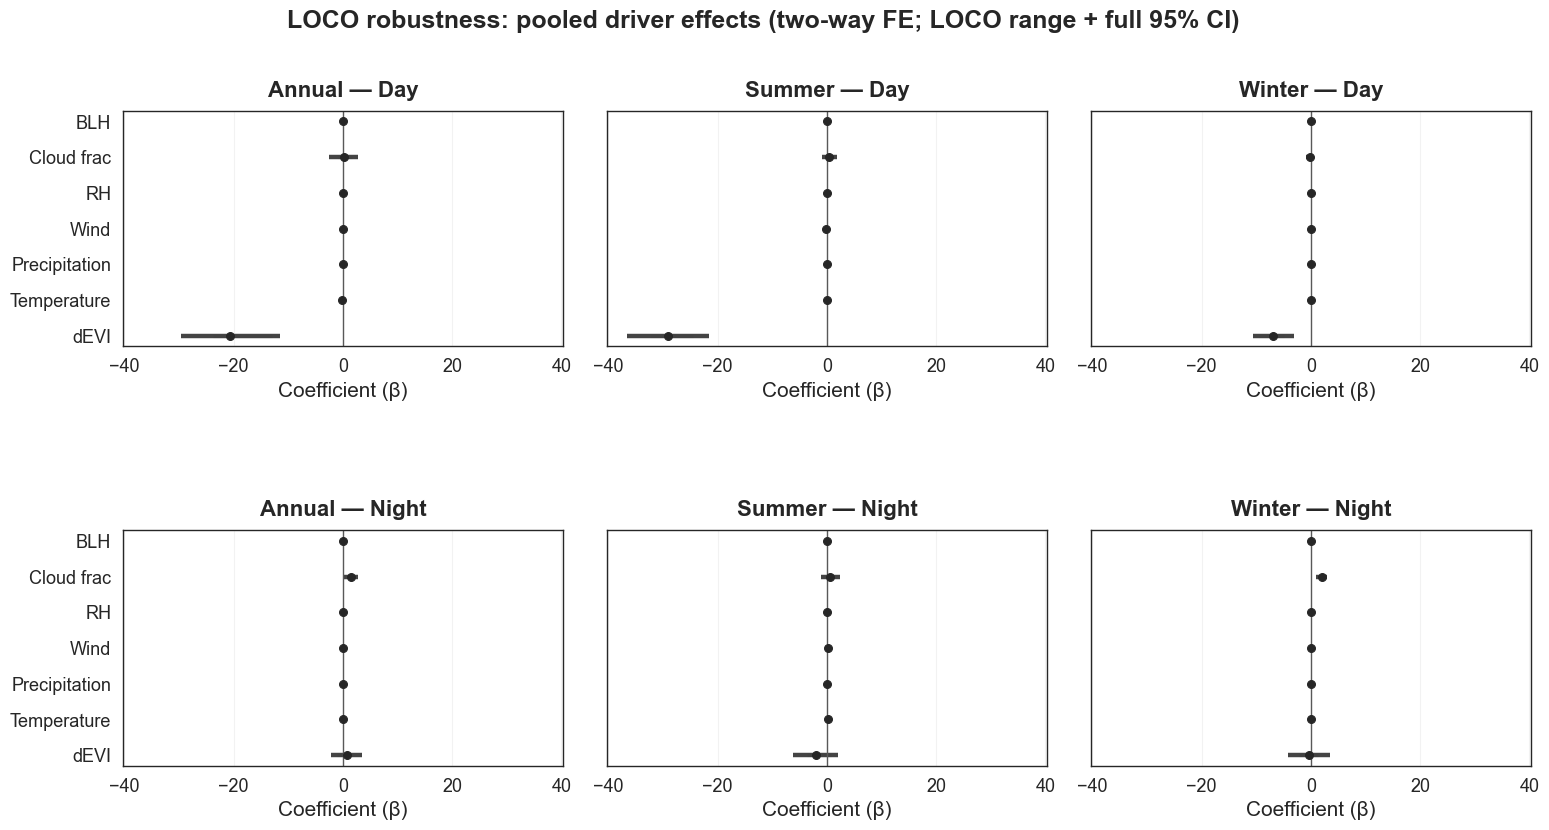

In [38]:

# =========================
# SUPP Fig — LOCO robustness (ONE figure)
# =========================
# We show:
#   - Full-sample pooled driver effects (β ± 95% CI; two-way FE; city-clustered SE)
#   - LOCO range (min/max β across leave-one-city-out refits)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

SEASONS = ["Annual", "Summer", "Winter"]
TODS = [("Day", YDAY), ("Night", YNIGHT)]

def _fit_fe_cluster(df, ycol, xvars, city_col="city"):
    d = df.dropna(subset=[ycol] + xvars + [city_col, "year"]).copy()
    d[city_col] = d[city_col].astype(str)
    d["year"] = pd.to_numeric(d["year"], errors="coerce").astype(int)
    f = f"{ycol} ~ " + " + ".join(xvars) + f" + C({city_col}) + C(year)"
    m = smf.ols(f, data=d).fit(cov_type="cluster", cov_kwds={"groups": d[city_col]})
    return m, d

def _coef_ci(m, v):
    b = float(m.params.get(v, np.nan))
    se = float(m.bse.get(v, np.nan))
    return b, b - 1.96 * se, b + 1.96 * se

def compute_loco_pooled_ranges(panel_df, season, ycol, xvars, city_col="city"):
    d0 = panel_df[panel_df["season"] == season].copy()
    m_full, d_full = _fit_fe_cluster(d0, ycol, xvars, city_col=city_col)
    cities = sorted(d_full[city_col].unique())

    rows = []
    for v in xvars:
        b, lo, hi = _coef_ci(m_full, v)
        rows.append({"var": v, "beta_full": b, "lo_full": lo, "hi_full": hi})
    out = pd.DataFrame(rows)

    betas = {v: [] for v in xvars}
    for drop_city in cities:
        dd = d0[d0[city_col].astype(str) != str(drop_city)].copy()
        if dd[city_col].nunique() < 3:
            continue
        try:
            m, _ = _fit_fe_cluster(dd, ycol, xvars, city_col=city_col)
        except Exception:
            continue
        for v in xvars:
            betas[v].append(float(m.params.get(v, np.nan)))

    out["beta_loco_min"] = out["var"].map(lambda v: np.nanmin(betas[v]) if len(betas[v]) else np.nan)
    out["beta_loco_max"] = out["var"].map(lambda v: np.nanmax(betas[v]) if len(betas[v]) else np.nan)
    out["label"] = out["var"].map(pretty_var)
    return out

def plot_loco_pooled_grid(panel_df, xvars, outpath=None,
                          title="LOCO robustness: pooled driver effects (two-way FE; LOCO range + full 95% CI)"):
    xvars = [v for v in xvars if v in panel_df.columns]
    if not xvars:
        raise ValueError("No xvars found in panel_df.")

    yvars = list(xvars)
    ylabels = [pretty_var(v) for v in yvars]
    y = np.arange(len(yvars))

    fig, axes = plt.subplots(2, 3, figsize=(16.0, 8.4), sharey=True)
    fig.suptitle(title, y=0.98, fontweight="bold")

    all_lo, all_hi = [], []
    cache = {}
    for r, (tod, ycol) in enumerate(TODS):
        for c, season in enumerate(SEASONS):
            tbl = compute_loco_pooled_ranges(panel_df, season=season, ycol=ycol, xvars=yvars)
            cache[(season, tod)] = tbl

            all_lo.extend(tbl["lo_full"].tolist())
            all_hi.extend(tbl["hi_full"].tolist())
            all_lo.extend(tbl["beta_loco_min"].tolist())
            all_hi.extend(tbl["beta_loco_max"].tolist())

    lim = np.nanmax(np.abs(np.r_[all_lo, all_hi])) if len(all_lo) else 1.0
    lim = max(lim, 0.5) * 1.10

    for r, (tod, ycol) in enumerate(TODS):
        for c, season in enumerate(SEASONS):
            ax = axes[r, c]
            tbl = cache[(season, tod)].set_index("var").reindex(yvars).reset_index()

            ax.hlines(y, tbl["beta_loco_min"], tbl["beta_loco_max"], lw=2.2, color="0.70", alpha=0.95)
            ax.hlines(y, tbl["lo_full"], tbl["hi_full"], lw=3.2, color="0.25", alpha=0.98)
            ax.scatter(tbl["beta_full"], y, s=32, color="0.15", zorder=3)

            ax.axvline(0, lw=1.0, color="0.35")
            ax.set_xlim(-lim, lim)
            ax.grid(True, axis="x", alpha=0.25)
            ax.set_title(f"{season} — {tod}", fontweight="bold", pad=10)

            ax.set_yticks(y)
            if c == 0:
                ax.set_yticklabels(ylabels)
            else:
                ax.tick_params(labelleft=False)

            ax.set_xlabel("Coefficient (β)")

    fig.subplots_adjust(top=0.86, bottom=0.08, left=0.10, right=0.98, hspace=0.78, wspace=0.10)
    if outpath:
        apply_large_figure_text(fig)
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print("Saved:", outpath)
    return fig

fig = plot_loco_pooled_grid(
    panel,
    xvars=[v for v in XFULL if v in panel.columns],
    outpath=str(FIG_SUPP / "SuppFig_LOCO_PooledEffects_Grid.png")
)
plt.show()


Saved: paper_outputs_final\figures_supp\SuppFig_LOCO_CityHeterogeneity_Grid.png


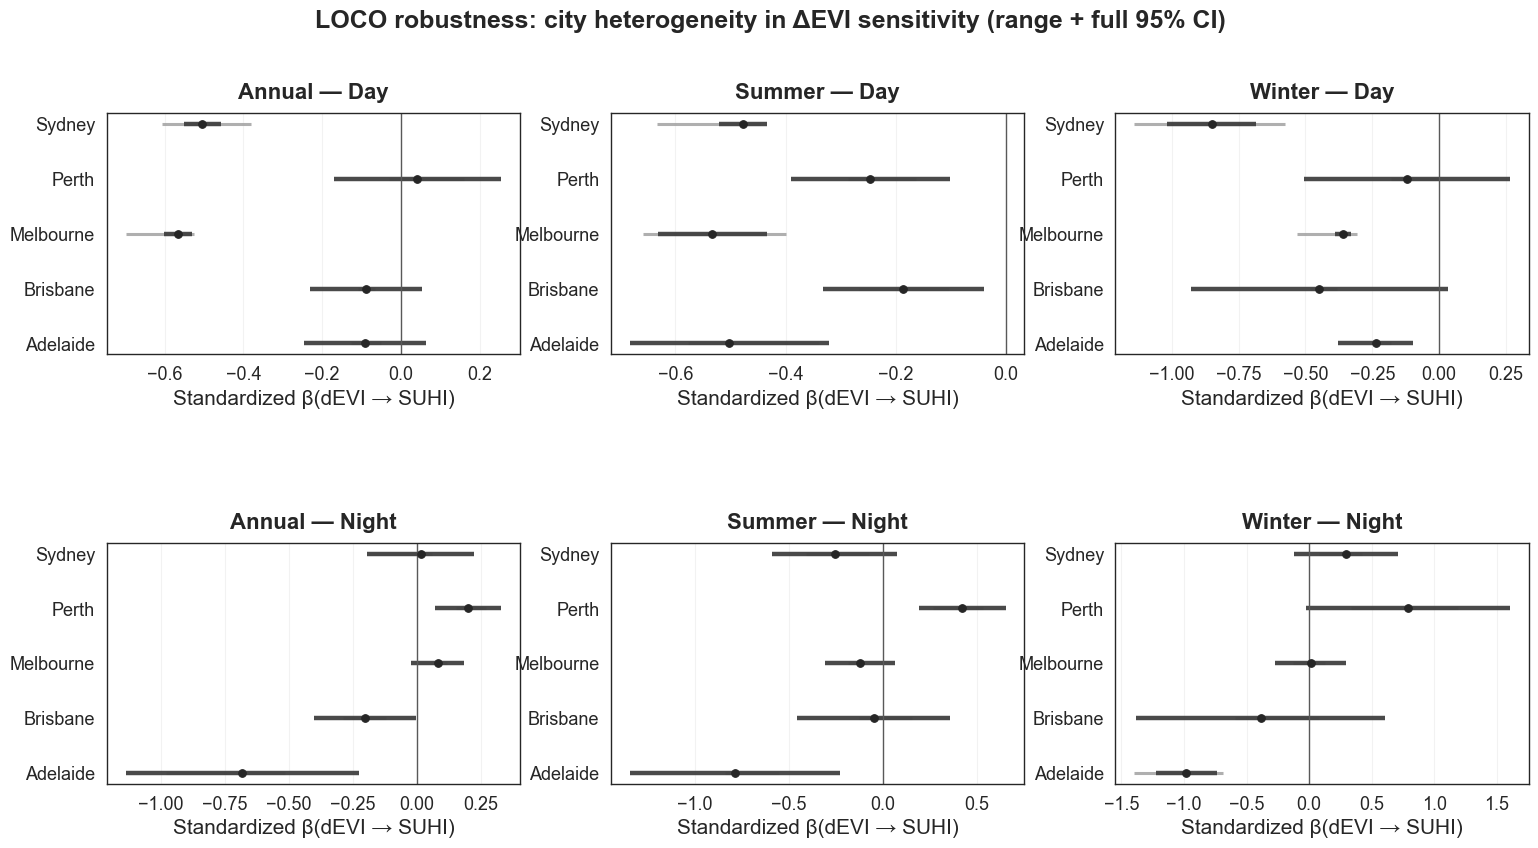

In [39]:

# =========================
# SUPP Fig — LOCO robustness for CITY HETEROGENEITY (ΔEVI slopes)
# =========================
# For each (season, tod):
#   - Fit full interaction model: y ~ dEVI*C(city) + met + FE(year)
#   - Extract city-specific ΔEVI slope and 95% CI (clustered by city)
#   - Refit leaving one city out (LOCO); compute min/max of each city's slope across LOCO runs
# Output: 2×3 grid.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import zscore

SEASONS = ["Annual","Summer","Winter"]
TODS = [("Day", YDAY), ("Night", YNIGHT)]
EVI_INT = EVI_COL if "EVI_COL" in globals() else "dEVI_mean"

def _safe_z(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").astype(float).values
    s = np.nanstd(x)
    if not np.isfinite(s) or s == 0:
        return x*0.0
    return zscore(x, nan_policy="omit")

def fit_city_interaction(df, ycol, xvars, x_int=EVI_INT, city_col="city", cluster_col="city"):
    dd = df.dropna(subset=[ycol, city_col, "year"] + list(xvars)).copy()
    cols = [ycol] + list(xvars)
    for c in cols:
        dd[c] = _safe_z(dd[c].values)

    if x_int not in xvars:
        raise ValueError(f"x_int={x_int} must be included in xvars.")

    met_vars = [v for v in xvars if v != x_int]
    f = f"{ycol} ~ {x_int}*C({city_col})"
    if met_vars:
        f += " + " + " + ".join(met_vars)
    f += " + C(year)"
    m = smf.ols(f, data=dd).fit(cov_type="cluster", cov_kwds={"groups": dd[cluster_col]})
    return m, dd

def city_slopes_from_interaction(m, cities, x_int=EVI_INT, city_col="city"):
    params = m.params
    cov = m.cov_params()
    idx = params.index

    base = cities[0]
    rows=[]
    for c in cities:
        a = pd.Series(0.0, index=idx)
        a[x_int] = 1.0
        if c != base:
            term = f"{x_int}:C({city_col})[T.{c}]"
            if term in a.index:
                a[term] = 1.0
        slope = float((a*params).sum())
        var = float(a.values @ cov.values @ a.values)
        se = np.sqrt(var) if var >= 0 else np.nan
        rows.append({"city": c, "slope": slope, "se": se})
    out = pd.DataFrame(rows)
    out["lo"] = out["slope"] - 1.96*out["se"]
    out["hi"] = out["slope"] + 1.96*out["se"]
    return out

def compute_loco_city_slope_ranges(panel_df, season, ycol, xvars, x_int=EVI_INT, city_col="city"):
    d0 = panel_df[panel_df["season"]==season].dropna(subset=[city_col, "year", ycol, x_int]).copy()
    if d0.empty or d0[city_col].nunique() < 3:
        return None

    cities = sorted(d0[city_col].unique())
    full_m, _ = fit_city_interaction(d0, ycol=ycol, xvars=xvars, x_int=x_int, city_col=city_col, cluster_col=city_col)
    full_sl = city_slopes_from_interaction(full_m, cities=cities, x_int=x_int, city_col=city_col)
    full_sl = full_sl.set_index("city")

    ranges = {c: [] for c in cities}
    for drop_city in cities:
        dd = d0[d0[city_col] != drop_city].copy()
        if dd[city_col].nunique() < 3:
            continue
        try:
            m, _ = fit_city_interaction(dd, ycol=ycol, xvars=xvars, x_int=x_int, city_col=city_col, cluster_col=city_col)
            sl = city_slopes_from_interaction(m, cities=sorted(dd[city_col].unique()), x_int=x_int, city_col=city_col)
        except Exception:
            continue
        for _, r in sl.iterrows():
            ranges[r["city"]].append(float(r["slope"]))

    out = full_sl.reset_index().rename(columns={"index":"city"})
    out["loco_min"] = out["city"].map(lambda c: np.nanmin(ranges[c]) if len(ranges[c]) else np.nan)
    out["loco_max"] = out["city"].map(lambda c: np.nanmax(ranges[c]) if len(ranges[c]) else np.nan)
    return out

def plot_loco_city_heterogeneity(panel_df, outpath=None, xvars=None, x_int=EVI_INT):
    if xvars is None:
        xvars = [v for v in XFULL if v in panel_df.columns]
        if x_int not in xvars:
            xvars = [x_int] + xvars

    fig, axes = plt.subplots(2, 3, figsize=(15.8, 8.6), sharey=False)
    fig.suptitle("LOCO robustness: city heterogeneity in ΔEVI sensitivity (range + full 95% CI)",
                 y=0.98, fontweight="bold")

    for r, (tod, ycol) in enumerate(TODS):
        for c, season in enumerate(SEASONS):
            ax = axes[r, c]
            tbl = compute_loco_city_slope_ranges(panel_df, season=season, ycol=ycol, xvars=xvars, x_int=x_int)
            if tbl is None or tbl.empty:
                ax.axis("off")
                continue

            cities = sorted(tbl["city"].unique())
            tbl = tbl.set_index("city").reindex(cities).reset_index()

            y = np.arange(len(cities))
            ax.hlines(y, tbl["loco_min"], tbl["loco_max"], lw=2.2, color="0.65", alpha=0.9)
            ax.hlines(y, tbl["lo"], tbl["hi"], lw=3.2, color="0.25", alpha=0.95)
            ax.scatter(tbl["slope"], y, s=30, color="0.15", zorder=3)

            ax.axvline(0, lw=1.0, color="0.35")
            ax.grid(True, axis="x", alpha=0.25)
            ax.set_title(f"{season} — {tod}", fontweight="bold", pad=10)
            ax.set_yticks(y)
            ax.set_yticklabels(cities)
            ax.set_xlabel("Standardized β(dEVI → SUHI)")

    fig.subplots_adjust(top=0.86, bottom=0.08, left=0.08, right=0.98, hspace=0.78, wspace=0.22)
    if outpath:
        apply_large_figure_text(fig)
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print("Saved:", outpath)
    return fig

fig = plot_loco_city_heterogeneity(panel, outpath=str(FIG_SUPP / "SuppFig_LOCO_CityHeterogeneity_Grid.png"))
plt.show()


In [40]:
# =========================
# This block creates a compact set of composite figures:
#   Fig A: Time series (Day & Night) by season with city lines + pooled loess-like smooth
#   Fig B: Driver standardized effects (cluster_city) by season and day/night (dot-whisker panels)

import numpy as np
import matplotlib.pyplot as plt

def pooled_trend(panel, ycol):
    d = panel.dropna(subset=[ycol]).copy()
    g = d.groupby("year", as_index=False)[ycol].mean()
    return g

def fig_timeseries_composite(panel):
    seasons = ["Annual","Summer","Winter"]
    fig, axes = plt.subplots(3, 2, figsize=(13.5, 9.0), sharex=True)
    for i, season in enumerate(seasons):
        ds = panel[panel["season"]==season].copy()
        for j, (ycol, ttl) in enumerate([(YDAY,"Day"), (YNIGHT,"Night")]):
            ax = axes[i, j]
            # city lines
            for city, g in ds.groupby("city"):
                g = g.sort_values("year")
                ax.plot(g["year"], g[ycol], lw=1.2, alpha=0.25)
            # pooled mean
            g0 = pooled_trend(ds, ycol)
            ax.plot(g0["year"], g0[ycol], lw=2.6, alpha=0.95)
            ax.axhline(0, lw=1.0)
            ax.set_title(f"{season} — {ttl}", fontweight="bold")
            ax.grid(True, axis="y")
            ax.grid(False, axis="x")
            if j==0:
                ax.set_ylabel("SUHI (°C)")
    axes[-1,0].set_xlabel("Year")
    axes[-1,1].set_xlabel("Year")
    fig.tight_layout()
    save_fig_multi(fig, FIG_MAIN/"FigA_Timeseries_AllSeasons_DayNight", close=True)
    print("Saved: FigA_Timeseries_AllSeasons_DayNight.(png/pdf/svg)")

def fig_effects_composite(dk_tbl):
    seasons = ["Annual","Summer","Winter"]
    cov="cluster_city"
    terms = [t for t in ["dEVI_mean","t2m_C_mean","precip_mm_mean","wind10_ms_mean","rh_pct_mean","cloud_frac_mean","blh_m_mean"] if t in XFULL]
    fig, axes = plt.subplots(3, 2, figsize=(13.5, 9.0))
    for i, season in enumerate(seasons):
        for j, (ycol, ttl) in enumerate([(YDAY,"Day"), (YNIGHT,"Night")]):
            ax = axes[i, j]
            dd = dk_tbl[(dk_tbl["season"]==season) & (dk_tbl["y"]==ycol) & (dk_tbl["cov"]==cov) & (dk_tbl["term"].isin(terms))].copy()
            if dd.empty:
                ax.axis("off")
                continue
            dd = dd.sort_values("coef")
            coef = to_float_array(dd["coef"])
            se   = to_float_array(dd["se"])
            ci = 1.96*to_float_array(se)
            y = np.arange(len(dd))
            ax.hlines(y, coef-ci, coef+ci, lw=2)
            ax.scatter(coef, y, s=45, zorder=3)
            ax.axvline(0, lw=1.0)
            ax.set_yticks(y)
            ax.set_yticklabels(dd["term"])
            ax.set_title(f"{season} — {ttl}", fontweight="bold")
            ax.grid(True, axis="x")
            ax.grid(False, axis="y")
            if j==0:
                ax.set_xlabel("Standardized coefficient (95% CI)")
    fig.tight_layout()
    save_fig_multi(fig, FIG_MAIN/"FigB_Effects_AllSeasons_DayNight_cluster", close=True)
    print("Saved: FigB_Effects_AllSeasons_DayNight_cluster.(png/pdf/svg)")

# Run composites if needed tables exist
if "panel" in globals():
    fig_timeseries_composite(panel)
if "dk_tbl" in globals():
    fig_effects_composite(dk_tbl)

Saved: FigA_Timeseries_AllSeasons_DayNight.(png/pdf/svg)
Saved: FigB_Effects_AllSeasons_DayNight_cluster.(png/pdf/svg)
